In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression

from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams["font.family"] = "Candara"

BLUE_ACCENT  = "#003DA5"
RED_ACCENT   = "#C8102E"
AMBER_ACCENT = "#E87722"
CARD_FILL    = "#FFFFFF"
LABEL_COLOR  = "#4A4A4A"
SUB_COLOR    = "#888780"
BG_COLOR     = "#F0F2F5"

In [2]:
df = pd.read_csv("processed_data_5.csv")

In [3]:
df.head()

,uid,survey_type,start_time,biggest_challenge,live_work_sm,alice,feel_heard,community,age_group,race_ethnicity,...,community_Older Adults (+65),community_Other,community_Parents,community_Recovery Community,community_Town of Residence,community_White,community_Women,community_Youth (under 18),zip_code_full,county
0,CASH1,CASH,45889 days 16:18:22,NaN,Other Maine County,Yes,Yes,65 plus We often have reduced income but with ...,NaN,NaN,...,1,0,0,0,0,0,0,0,4103.0,Cumberland
1,CASH2,CASH,45889 days 16:18:49,NaN,Other Maine County,"Maybe, with difficulty",Maybe,the Village of Gray,NaN,NaN,...,0,0,0,0,1,0,0,0,4039.0,Cumberland
2,CASH3,CASH,45889 days 16:43:22,NaN,Other Maine County,No,Yes,South Portland,NaN,NaN,...,0,0,0,0,1,0,0,0,4106.0,Cumberland
3,CASH4,CASH,45889 days 16:57:55,NaN,Other Maine County,"Maybe, with difficulty",No,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,4103.0,Cumberland
4,CASH5,CASH,45889 days 18:58:47,NaN,Other Maine County,No,Yes,People living with Long Covid,NaN,NaN,...,0,1,0,0,0,0,0,0,4103.0,Cumberland


In [4]:
for col in df.columns:
    print(col)

uid
survey_type
start_time
biggest_challenge
live_work_sm
alice
feel_heard
community
age_group
race_ethnicity
relation_uwsm
want_involvement
how_involvement
hardest_expenses
zip_code
employed
employment_type
roadblock_expenses
helpful_supports
biggest_challenge_clean
live_work_sm_clean
alice_clean
feel_heard_clean
age_group_clean
race_ethnicity_clean
relation_uwsm_clean
want_involvement_clean
how_involvement_clean
hardest_expenses_clean
employed_clean
employment_type_clean
roadblock_expenses_clean
helpful_supports_clean
biggest_challenge_Affordable Child Care Access
biggest_challenge_Affordable Elder Care Access
biggest_challenge_Affordable Housing Availability
biggest_challenge_Behavioral Health
biggest_challenge_Climate Impacts
biggest_challenge_Cost of Basics
biggest_challenge_Domestic Violence
biggest_challenge_Education Access
biggest_challenge_Food Access
biggest_challenge_Gas Costs
biggest_challenge_Healthcare Cost
biggest_challenge_Housing Cost
biggest_challenge_Immigration Enf

In [4]:
df_sm = df[df['live_work_sm_clean'] != 'Outside Southern Maine']

### Total Participants

In [6]:
# no. of people who answered survey
print(len(df))

1889


In [7]:
# no of people in southern maine
print(len(df_sm))

1702


###  Alice Distribution

In [8]:
alice_proportions = df_sm['alice_clean'].value_counts(normalize=True)
print(alice_proportions)
alice_numbers = df_sm['alice_clean'].value_counts()
print(alice_numbers)

Above ALICE    0.698102
Below ALICE    0.301898
Name: alice_clean, dtype: float64
Above ALICE    1177
Below ALICE     509
Name: alice_clean, dtype: int64


### Top Challenges

In [9]:
biggest_challenges_cols = [c for c in df_sm.columns if c.startswith('biggest_challenge_')]
df_sm[biggest_challenges_cols].sum().sort_values(ascending=False)

biggest_challenge_Housing Cost                       1131
biggest_challenge_Cost of Basics                      852
biggest_challenge_Healthcare Cost                     688
biggest_challenge_Mental Health                       590
biggest_challenge_Affordable Child Care Access        513
biggest_challenge_Low Wages                           348
biggest_challenge_Behavioral Health                   279
biggest_challenge_Affordable Elder Care Access        252
biggest_challenge_Food Access                         239
biggest_challenge_Social Isolation                    199
biggest_challenge_Transportation                      188
biggest_challenge_Job Instability                     152
biggest_challenge_Education Access                     36
biggest_challenge_Climate Impacts                      26
biggest_challenge_Lack of in Home Support              17
biggest_challenge_Other                                16
biggest_challenge_Affordable Housing Availability      13
biggest_challe

### Engagement Preferences

##### Relation to UWSM

In [10]:
# THIS IS FOR ENTIRE DATASET
df['relation_uwsm'].value_counts()

Not Connected           323
Moderately Connected    118
Closely Connected        91
Name: relation_uwsm, dtype: int64

In [11]:
# THIS IS FOR THOsE THAT LIVE/WORK IN SOUTHERN MAINE
df_sm['relation_uwsm'].value_counts()

Not Connected           300
Moderately Connected    113
Closely Connected        89
Name: relation_uwsm, dtype: int64

##### Want to get Involved?

In [12]:
# THIS IS FOR LIVE/WORK IN SOUTHERN MAINE
df_sm['want_involvement'].value_counts()

No     413
Yes     99
Name: want_involvement, dtype: int64

In [13]:
# THIS IS FOR ENTIRE DATASET
df['want_involvement'].value_counts()

No     447
Yes    104
Name: want_involvement, dtype: int64

##### How do you want to be involved?

In [14]:
# THIS IS FOR THOSE THAT LIVE/WORK IN SM
involvements_cols = [c for c in df_sm.columns if c.startswith('how_involvement')]
df_sm[involvements_cols].sum().sort_values(ascending=False)

how_involvement_Volunteer      98
how_involvement_Join Group     52
how_involvement_Speak Up       47
how_involvement_Donate         41
how_involvement_Share Story    30
how_involvement_Connect        12
dtype: int64

In [15]:
# THIS IS FOR ENTIRE DATASET
involvements_cols = [c for c in df.columns if c.startswith('how_involvement')]
df[involvements_cols].sum().sort_values(ascending=False)

how_involvement_Volunteer      113
how_involvement_Join Group      60
how_involvement_Speak Up        54
how_involvement_Donate          45
how_involvement_Share Story     31
how_involvement_Connect         13
dtype: int64

### County / Geography

In [16]:
# unfiltered
print(df['county'].value_counts())

Cumberland                64
York                      14
Outside Southern Maine     5
Name: county, dtype: int64


In [17]:
# live work in SM
df_sm['live_work_sm_clean'].value_counts()

Cumberland           1114
York                  514
Cumberland & York      73
Name: live_work_sm_clean, dtype: int64

In [18]:
# SAME AS ENTIRE DATASET
df['live_work_sm_clean'].value_counts()

Cumberland                1114
York                       514
Outside Southern Maine     187
Cumberland & York           73
Name: live_work_sm_clean, dtype: int64

### Demographic sub-groups

##### Race/Ethnicity

In [19]:
# THIS IS FOR THOSE THAT LIVE/WORK IN SM
race_ethnicity_cols = [c for c in df_sm.columns if c.startswith('race_ethnicity_')]
df_sm[race_ethnicity_cols].sum().sort_values(ascending=False)

race_ethnicity_White                   340
race_ethnicity_BIPOC                    30
race_ethnicity_Prefer not to answer     13
race_ethnicity_Other                     5
race_ethnicity_More than one             1
dtype: int64

In [20]:
# THIS IS FOR ENTIRE DATASET
race_ethnicity_cols = [c for c in df.columns if c.startswith('race_ethnicity_')]
df[race_ethnicity_cols].sum().sort_values(ascending=False)

race_ethnicity_White                   351
race_ethnicity_BIPOC                    31
race_ethnicity_Prefer not to answer     13
race_ethnicity_Other                     5
race_ethnicity_More than one             1
dtype: int64

##### Age Group

In [21]:
# THIS IS FOR THOSE THAT LIVE/WORK IN SM
df_sm['age_group_clean'].value_counts()

25-64       489
Under 24    112
Over 65+     99
Name: age_group_clean, dtype: int64

In [22]:
# THIS IS FOR THE ENTIRE DATASET
df['age_group_clean'].value_counts()

25-64       505
Under 24    125
Over 65+    101
Name: age_group_clean, dtype: int64

### Employement

##### Employed?

In [23]:
# LIVE/WORK SM
df_sm['employed'].value_counts()

Series([], Name: employed, dtype: int64)

In [24]:
# ENITRE DATASET
df['employed'].value_counts()

Yes    45
No     38
Name: employed, dtype: int64

##### EMPLOYMENT TYPE

In [25]:
# LIVE/WORK SM
df_sm['employment_type'].value_counts()

Series([], Name: employment_type, dtype: int64)

In [26]:
# ENITRE DATASET
df['employment_type'].value_counts()

Full-time hours (40 or more) working for one employer              21
Full-time hours (40 or more) working for more than one employer     8
Part-time hours (29 or less)                                        8
Self employed                                                       2
Per diem                                                            2
Freelance/contract                                                  1
a mixture of part time and self-employed                            1
32 hours                                                            1
I am election clerk working 3 times a year                          1
Name: employment_type, dtype: int64

### Feeling Heard?

In [27]:
# THIS IS FOR LIVE/WORK SM
print(df_sm['feel_heard'].value_counts())
print()
print(df_sm['feel_heard_clean'].value_counts())

No       547
Yes      226
Maybe     89
Name: feel_heard, dtype: int64

Unheard    636
Heard      226
Name: feel_heard_clean, dtype: int64


In [28]:
# ENTIRE DATASET
print(df['feel_heard'].value_counts())
print()
print(df['feel_heard_clean'].value_counts())

No       621
Yes      257
Maybe    126
Name: feel_heard, dtype: int64

Unheard    747
Heard      257
Name: feel_heard_clean, dtype: int64


### What communty are you referring to ?

In [29]:
# THESE ARE THE NUMBERS FOR THOSE IN SOUTHERN MAINE
community_cols = [c for c in df_sm.columns if c.startswith('community_')]
df_sm[community_cols].sum().sort_values(ascending=False)

community_Other                 95
community_Town of Residence     87
community_Women                 20
community_Older Adults (+65)    16
community_LGBTQ+                16
community_BIPOC                 12
community_Youth (under 18)       9
community_Parents                9
community_Recovery Community     3
community_ALICE                  2
community_White                  1
community_Hispanic               1
community_African American       0
dtype: int64

In [30]:
# THIS IS FOR OVERALL (IN MAINE)
community_cols = [c for c in df.columns if c.startswith('community_')]
df[community_cols].sum().sort_values(ascending=False)

community_Town of Residence     117
community_Other                 113
community_Older Adults (+65)     27
community_Women                  23
community_LGBTQ+                 20
community_BIPOC                  13
community_Youth (under 18)       12
community_Parents                10
community_Recovery Community      3
community_ALICE                   2
community_White                   1
community_Hispanic                1
community_African American        1
dtype: int64

### Roadblocks in Paying Expenses/Bills

In [31]:
# NOTE: THIS IS UNFILTERED DATA
# NONE OF THE ROWS THAT ARE "IN SOUTHERN MAINE"
# ANSWERED THE ROADBLOCK EXPENSES QUESTIONS
roadblocks_cols = [c for c in df.columns if c.startswith('roadblock_expenses_')]
df[roadblocks_cols].sum().sort_values(ascending=False)

roadblock_expenses_Health Issues or Disability                25
roadblock_expenses_Insufficient Income / Fixed Income         20
roadblock_expenses_Unaware of or Limited Job Opportunities    17
roadblock_expenses_High Cost of Living                        15
roadblock_expenses_Retirement Challenges                      14
roadblock_expenses_Lack of Skills or Training                 11
roadblock_expenses_Debt / Cash Flow Issues                    11
roadblock_expenses_Lack of Reliable Transportation             9
roadblock_expenses_Financially Stable / Doing Well             7
roadblock_expenses_Lack of Time for Training/Education         6
roadblock_expenses_Family Care Responsibilities                6
roadblock_expenses_Age-Related Employment Barriers             6
roadblock_expenses_Lack of Affordable Child Care               5
roadblock_expenses_Turned Away                                 1
roadblock_expenses_Other                                       1
dtype: int64

### Hardest Expenses

In [32]:
# NOTE: THIS IS UNFILTERED DATA
# NONE OF THE ROWS THAT ARE "IN SOUTHERN MAINE"
# ANSWERED THE HARDEST EXPENSES QUESTIONS
hardest_expenses_cols = [c for c in df.columns if c.startswith('hardest_expenses_')]
df[hardest_expenses_cols].sum().sort_values(ascending=False)

hardest_expenses_Housing costs (e.g., rent, mortgage)                                         39
hardest_expenses_Groceries/Food                                                               37
hardest_expenses_Transportation (e.g., car payments, gas, car repairs or public transport)    32
hardest_expenses_Utilities (e.g., electricity, water, gas)                                    30
hardest_expenses_Medical bills/Healthcare Costs                                               27
hardest_expenses_Insurance Premiums (Health, Car, Home, etc)                                  25
hardest_expenses_Credit Card or Loan Payments                                                 23
hardest_expenses_Phone or Internet Service                                                    22
hardest_expenses_Childcare or School-Related Expenses                                          5
dtype: int64

### Helpful Supports

In [33]:
# NOTE: THIS IS UNFILTERED DATA
# NONE OF THE ROWS THAT ARE "IN SOUTHERN MAINE"
# ANSWERED THE HELPFULL QUESTIONS
helpful_supports_cols = [c for c in df.columns if c.startswith('helpful_supports_')]
df[helpful_supports_cols].sum().sort_values(ascending=False)

helpful_supports_Food                      32
helpful_supports_Health/Mental Health      27
helpful_supports_Transportation            22
helpful_supports_Rental Assistance         21
helpful_supports_Job Training/Education    16
helpful_supports_Debt/Credit               16
helpful_supports_Home Ownership             8
helpful_supports_Employment                 8
helpful_supports_Increased Income           7
helpful_supports_Other                      6
helpful_supports_Taxes                      5
helpful_supports_SNAP/TANF Navigation       5
dtype: int64

### Visualizations section

##### Summary Metrics

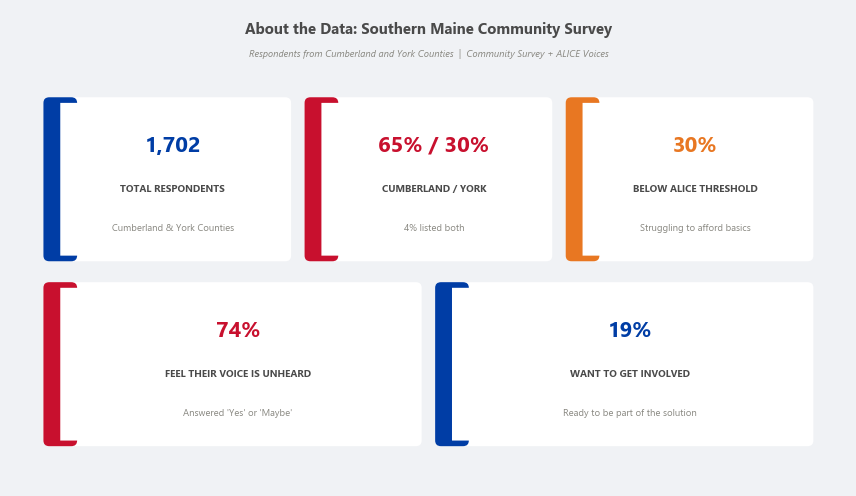

Saved: slide2_hero_stats.png


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import pandas as pd

plt.rcParams["font.family"] = "Segoe UI"

# ── COLORS ────────────────────────────────────────────────────────────────────
BLUE_ACCENT  = "#003DA5"
RED_ACCENT   = "#C8102E"
AMBER_ACCENT = "#E87722"
CARD_FILL    = "#FFFFFF"
LABEL_COLOR  = "#4A4A4A"
SUB_COLOR    = "#888780"
BG_COLOR     = "#F0F2F5"

# ── COMPUTE STATS ─────────────────────────────────────────────────────────────
total_n = len(df_sm)

region_pcts         = df_sm["live_work_sm_clean"].value_counts(normalize=True) * 100
cumberland_pct      = region_pcts.get("Cumberland", 0)
york_pct            = region_pcts.get("York", 0)
cumberland_and_york = region_pcts.get("Cumberland & York", 0)

alice_pcts      = df_sm["alice_clean"].value_counts(normalize=True) * 100
below_alice_pct = alice_pcts.get("Below ALICE", 0)

heard_pcts  = df_sm["feel_heard_clean"].value_counts(normalize=True) * 100
unheard_pct = heard_pcts.get("Unheard", 0)

involve_pcts      = df_sm["want_involvement_clean"].value_counts(normalize=True) * 100
want_involved_pct = involve_pcts.get("Yes", 0)

# ── STATS ─────────────────────────────────────────────────────────────────────
row1 = [
    (f"{total_n:,}",
     "TOTAL RESPONDENTS",
     "Cumberland & York Counties",
     BLUE_ACCENT),
    (f"{cumberland_pct:.0f}% / {york_pct:.0f}%",
     "CUMBERLAND / YORK",
     f"{cumberland_and_york:.0f}% listed both",
     RED_ACCENT),
    (f"{below_alice_pct:.0f}%",
     "BELOW ALICE THRESHOLD",
     "Struggling to afford basics",
     AMBER_ACCENT),
]
row2 = [
    (f"{unheard_pct:.0f}%",
     "FEEL THEIR VOICE IS UNHEARD",
     "Answered 'Yes' or 'Maybe'",
     RED_ACCENT),
    (f"{want_involved_pct:.0f}%",
     "WANT TO GET INVOLVED",
     "Ready to be part of the solution",
     BLUE_ACCENT),
]

# ── CARD FUNCTION ─────────────────────────────────────────────────────────────
def draw_card(ax, x, y, w, h, number, label, sublabel, accent):
    # Rounded white card
    card = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.07",
        linewidth=0, facecolor=CARD_FILL, zorder=2
    )
    ax.add_patch(card)

    # Accent bar at double width so right corners hide behind card
    bar_w = 0.13
    bar = mpatches.FancyBboxPatch(
        (x, y), bar_w * 2, h,
        boxstyle="round,pad=0.07",
        linewidth=0, facecolor=accent, zorder=3
    )
    ax.add_patch(bar)

    # White cover over right half of bar to square off right corners
    card2 = mpatches.FancyBboxPatch(
        (x + bar_w, y), w - bar_w, h,
        boxstyle="round,pad=0.0",
        linewidth=0, facecolor=CARD_FILL, zorder=4
    )
    ax.add_patch(card2)

    cx = x + bar_w + (w - bar_w) / 2   # horizontal center of text area

    # Big number — bold, colored
    ax.text(cx, y + h * 0.72, number,
            ha="center", va="center",
            fontsize=22, fontweight="bold",
            color=accent, zorder=5)

    # Label — bold, dark gray
    ax.text(cx, y + h * 0.44, label,
            ha="center", va="center",
            fontsize=10, fontweight="bold",
            color=LABEL_COLOR, zorder=5, linespacing=1.4)

    # Sublabel — regular weight, muted
    ax.text(cx, y + h * 0.18, sublabel,
            ha="center", va="center",
            fontsize=9.5, fontweight="normal",
            color=SUB_COLOR, zorder=5)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

# Title
ax.text(5, 5.72,
        "About the Data: Southern Maine Community Survey",
        ha="center", va="center",
        fontsize=15, fontweight="bold", color=LABEL_COLOR)

ax.text(5, 5.42,
        "Respondents from Cumberland and York Counties  |  Community Survey + ALICE Voices",
        ha="center", va="center",
        fontsize=9.5, color=SUB_COLOR, style="italic")

# ── LAYOUT & DRAW ─────────────────────────────────────────────────────────────
card_w = 2.8
card_h = 1.9
gap    = 0.3

# Row 1 — 3 cards
total_w1 = 3 * card_w + 2 * gap
start_x1 = (10 - total_w1) / 2
for i, (number, label, sublabel, accent) in enumerate(row1):
    x = start_x1 + i * (card_w + gap)
    draw_card(ax, x, 2.9, card_w, card_h, number, label, sublabel, accent)

# Row 2 — 2 cards stretched to match row 1 width
card_w2 = (total_w1 - gap) / 2
for i, (number, label, sublabel, accent) in enumerate(row2):
    x = start_x1 + i * (card_w2 + gap)
    draw_card(ax, x, 0.6, card_w2, card_h, number, label, sublabel, accent)

plt.tight_layout()
# plt.savefig("slide2_hero_stats.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: slide2_hero_stats.png")

In [39]:
def uw_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = [
        "#C8102E",  # UW red — biggest words
        "#E87722",  # UW amber — second biggest
        "#003DA5",  # UW blue
        "#1B7A4A",  # deep green
        "#6B2D8B",  # purple
        "#0093B2",  # teal — smallest words
    ]
    idx = int(font_size / 20) % len(colors)
    return colors[idx]

Above ALICE respondents: 1177
Top 10 challenges:
  Housing Cost: 767
  Cost of Basics: 556
  Healthcare Cost: 511
  Mental Health: 406
  Affordable Child Care Access: 399
  Low Wages: 231
  Affordable Elder Care Access: 203
  Behavioral Health: 193
  Social Isolation: 156
  Food Access: 132


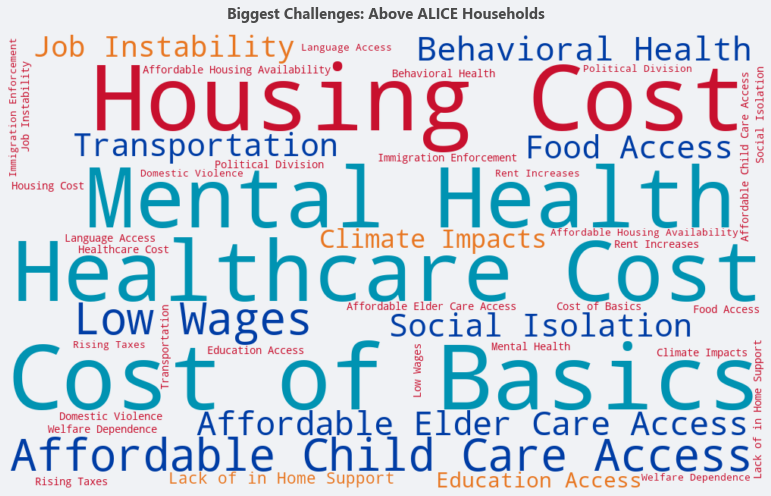

In [51]:
# ── FILTER ────────────────────────────────────────────────────────────────────
df_above = df_sm[df_sm["alice_clean"] == "Above ALICE"]

# ── FREQUENCIES ───────────────────────────────────────────────────────────────
labels_above = []
for entry in df_above["biggest_challenge_clean"].dropna():
    labels = [l.strip() for l in entry.split(";") if l.strip()]
    labels = [l for l in labels if l.lower() not in ["none", "other"]]
    labels_above.extend(labels)

freq_above = Counter(labels_above)

print(f"Above ALICE respondents: {len(df_above)}")
print("Top 10 challenges:")
for k, v in freq_above.most_common(10):
    print(f"  {k}: {v}")

# ── WORD CLOUD ────────────────────────────────────────────────────────────────
wc = WordCloud(
    width=1000,
    height=600,
    background_color=BG_COLOR,
    color_func=uw_color_func,
    max_words=40,
    prefer_horizontal=0.65,
    min_font_size=12,
    max_font_size=120,
    collocations=False,
    repeat=True,
).generate_from_frequencies(freq_above)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

ax.set_title(
    "Biggest Challenges: Above ALICE Households",
    fontsize=15, fontweight="bold", color=LABEL_COLOR, pad=16
)

plt.tight_layout()
# plt.savefig("slide4_above_alice_wordcloud_final.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

Below ALICE respondents: 509
Top 10 challenges:
  Housing Cost: 350
  Cost of Basics: 283
  Mental Health: 177
  Healthcare Cost: 166
  Affordable Child Care Access: 110
  Low Wages: 110
  Food Access: 105
  Behavioral Health: 85
  Transportation: 72
  Affordable Elder Care Access: 46


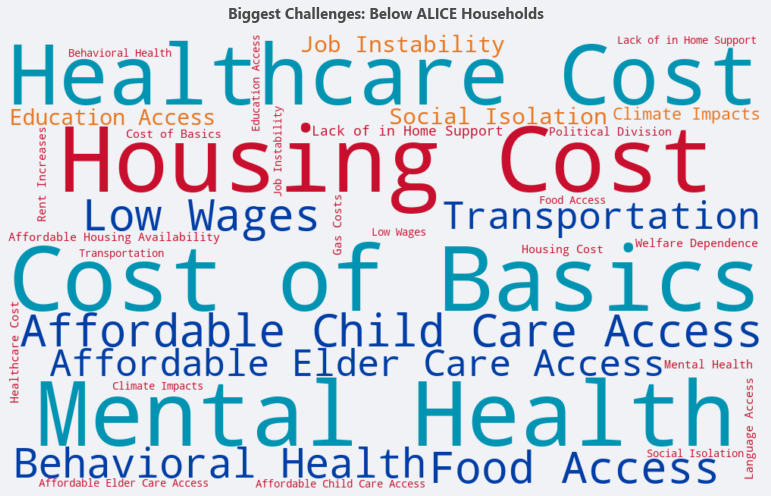

In [55]:
df_below = df_sm[df_sm["alice_clean"] == "Below ALICE"]

# ── FREQUENCIES ───────────────────────────────────────────────────────────────
labels_below = []
for entry in df_below["biggest_challenge_clean"].dropna():
    labels = [l.strip() for l in entry.split(";") if l.strip()]
    labels = [l for l in labels if l.lower() not in ["none", "other"]]
    labels_below.extend(labels)

freq_below = Counter(labels_below)

print(f"Below ALICE respondents: {len(df_below)}")
print("Top 10 challenges:")
for k, v in freq_below.most_common(10):
    print(f"  {k}: {v}")

# ── WORD CLOUD ────────────────────────────────────────────────────────────────
wc = WordCloud(
    width=1000,
    height=600,
    background_color=BG_COLOR,
    color_func=uw_color_func,
    max_words=40,
    prefer_horizontal=0.65,
    min_font_size=12,
    max_font_size=120,
    collocations=False,
    repeat=True,
).generate_from_frequencies(freq_below)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

ax.set_title(
    "Biggest Challenges: Below ALICE Households",
    fontsize=15, fontweight="bold", color=LABEL_COLOR, pad=16
)

plt.tight_layout()
# plt.savefig("slide4_below_alice_wordcloud_final.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

In [56]:
total_below = 509
total_above = 1177

challenges = [
    "Housing Cost", "Cost of Basics", "Mental Health", "Healthcare Cost",
    "Affordable Child Care Access", "Low Wages", "Food Access",
    "Behavioral Health", "Transportation", "Affordable Elder Care Access",
    "Social Isolation"
]

below_counts = [350, 283, 177, 166, 110, 110, 105, 85, 72, 46, 0]
above_counts = [767, 556, 406, 511, 399, 231, 132, 193, 0, 203, 156]

below_pct = [round(c / total_below * 100, 1) for c in below_counts]
above_pct = [round(c / total_above * 100, 1) for c in above_counts]

for c, b, a in zip(challenges, below_pct, above_pct):
    print(f"{c:<35} Below: {b}%   Above: {a}%   Diff: {b-a:+.1f}%")

Housing Cost                        Below: 68.8%   Above: 65.2%   Diff: +3.6%
Cost of Basics                      Below: 55.6%   Above: 47.2%   Diff: +8.4%
Mental Health                       Below: 34.8%   Above: 34.5%   Diff: +0.3%
Healthcare Cost                     Below: 32.6%   Above: 43.4%   Diff: -10.8%
Affordable Child Care Access        Below: 21.6%   Above: 33.9%   Diff: -12.3%
Low Wages                           Below: 21.6%   Above: 19.6%   Diff: +2.0%
Food Access                         Below: 20.6%   Above: 11.2%   Diff: +9.4%
Behavioral Health                   Below: 16.7%   Above: 16.4%   Diff: +0.3%
Transportation                      Below: 14.1%   Above: 0.0%   Diff: +14.1%
Affordable Elder Care Access        Below: 9.0%   Above: 17.2%   Diff: -8.2%
Social Isolation                    Below: 0.0%   Above: 13.3%   Diff: -13.3%


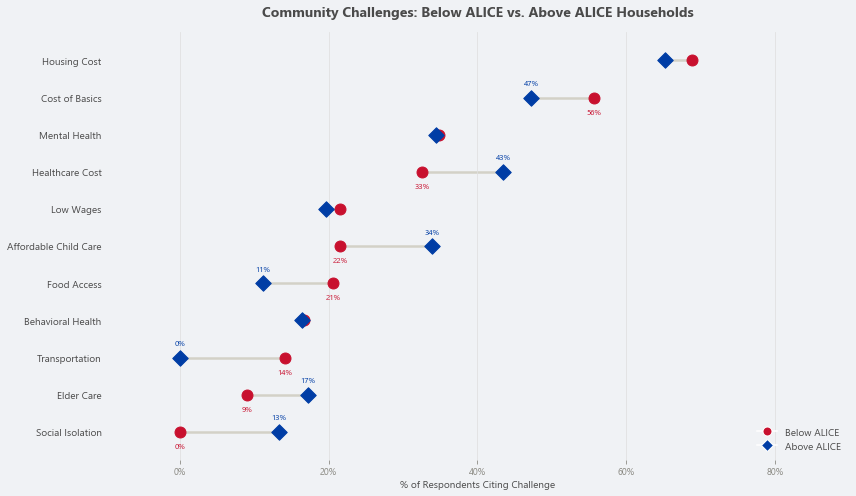

Saved: slide5_dumbbell.png


In [60]:
challenges = [
    'Housing Cost', 'Cost of Basics', 'Mental Health', 'Healthcare Cost',
    'Affordable Child Care', 'Low Wages', 'Food Access', 'Behavioral Health',
    'Transportation', 'Elder Care', 'Social Isolation'
]
below = [68.8, 55.6, 34.8, 32.6, 21.6, 21.6, 20.6, 16.7, 14.1,  9.0,  0.0]
above = [65.2, 47.2, 34.5, 43.4, 33.9, 19.6, 11.2, 16.4,  0.0, 17.2, 13.3]

# Sort by Below ALICE value descending for cleaner layout
pairs = sorted(zip(challenges, below, above), key=lambda x: x[1])
challenges, below, above = zip(*pairs)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

y_pos = range(len(challenges))

# Connecting line between dots
for i, (b, a) in enumerate(zip(below, above)):
    ax.plot([b, a], [i, i],
            color="#D3D1C7", linewidth=2.5, zorder=1)

# Below ALICE dots — red circles
ax.scatter(below, y_pos,
           color=RED_ACCENT, s=120, zorder=3,
           label="Below ALICE")

# Above ALICE dots — blue diamonds
ax.scatter(above, y_pos,
           color=BLUE_ACCENT, s=120, zorder=3,
           marker="D", label="Above ALICE")

# Below ALICE labels sit below the line, Above ALICE labels sit above
# Skip labels when gap is less than 5% to avoid clutter
for i, (b, a) in enumerate(zip(below, above)):
    if abs(b - a) < 5:
        continue
    offset = 0.28
    ax.text(b, i - offset, f"{b:.0f}%",
            ha="center", va="top",
            fontsize=8, color=RED_ACCENT)
    ax.text(a, i + offset, f"{a:.0f}%",
            ha="center", va="bottom",
            fontsize=8, color=BLUE_ACCENT)

# ── AXES STYLING ──────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(challenges, fontsize=10, color=LABEL_COLOR)
ax.set_xlabel("% of Respondents Citing Challenge", fontsize=10, color=LABEL_COLOR)
ax.set_xlim(-10, 90)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}%"))
ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax.tick_params(axis="y", length=0)

# Light vertical grid lines only
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── TITLE ─────────────────────────────────────────────────────────────────────
ax.set_title(
    "Community Challenges: Below ALICE vs. Above ALICE Households",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16
)

# ── LEGEND ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=RED_ACCENT,
           markersize=9, label="Below ALICE"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=BLUE_ACCENT,
           markersize=9, label="Above ALICE"),
]
leg = ax.legend(handles=legend_elements, loc="lower right",
                frameon=False, fontsize=10)
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

plt.tight_layout()
# plt.savefig("slide5_dumbbell.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
# print("Saved: slide5_dumbbell.png")

In [61]:
age_cols = [c for c in df_sm.columns if c.startswith("biggest_challenge_")]

age_groups = df_sm["age_group_clean"].dropna().unique()
print("Age groups:", age_groups)

for age in sorted(age_groups):
    subset = df_sm[df_sm["age_group_clean"] == age]
    total = len(subset)
    print(f"\n── {age} (n={total}) ──")
    labels = []
    for entry in subset["biggest_challenge_clean"].dropna():
        labels += [l.strip() for l in entry.split(";") if l.strip() and l.strip().lower() not in ["none", "other"]]
    freq = Counter(labels)
    for k, v in freq.most_common(5):
        print(f"  {k}: {v} ({v/total*100:.1f}%)")

Age groups: ['25-64' 'Over 65+' 'Under 24']

── 25-64 (n=489) ──
  Housing Cost: 251 (51.3%)
  Cost of Basics: 192 (39.3%)
  Affordable Child Care Access: 147 (30.1%)
  Healthcare Cost: 143 (29.2%)
  Mental Health: 140 (28.6%)

── Over 65+ (n=99) ──
  Housing Cost: 54 (54.5%)
  Healthcare Cost: 39 (39.4%)
  Cost of Basics: 38 (38.4%)
  Affordable Elder Care Access: 21 (21.2%)
  Affordable Child Care Access: 19 (19.2%)

── Under 24 (n=112) ──
  Housing Cost: 14 (12.5%)
  Cost of Basics: 12 (10.7%)
  Mental Health: 9 (8.0%)
  Healthcare Cost: 8 (7.1%)
  Low Wages: 5 (4.5%)


In [62]:
race_groups = df_sm["race_ethnicity_clean"].dropna().unique()
print("Race groups:", race_groups)

for race in sorted(race_groups):
    subset = df_sm[df_sm["race_ethnicity_clean"] == race]
    total = len(subset)
    print(f"\n── {race} (n={total}) ──")
    labels = []
    for entry in subset["biggest_challenge_clean"].dropna():
        labels += [l.strip() for l in entry.split(";") if l.strip() and l.strip().lower() not in ["none", "other"]]
    freq = Counter(labels)
    for k, v in freq.most_common(5):
        print(f"  {k}: {v} ({v/total*100:.1f}%)")

Race groups: ['White' 'Other' 'Prefer not to answer' 'BIPOC' 'More than one;White']

── BIPOC (n=30) ──
  Housing Cost: 29 (96.7%)
  Cost of Basics: 19 (63.3%)
  Healthcare Cost: 14 (46.7%)
  Affordable Child Care Access: 11 (36.7%)
  Mental Health: 11 (36.7%)

── More than one;White (n=1) ──
  Affordable Elder Care Access: 1 (100.0%)
  Housing Cost: 1 (100.0%)
  Healthcare Cost: 1 (100.0%)
  Mental Health: 1 (100.0%)
  Social Isolation: 1 (100.0%)

── Other (n=5) ──
  Housing Cost: 3 (60.0%)
  Social Isolation: 3 (60.0%)
  Affordable Elder Care Access: 2 (40.0%)
  Transportation: 2 (40.0%)
  Healthcare Cost: 2 (40.0%)

── Prefer not to answer (n=13) ──
  Housing Cost: 11 (84.6%)
  Low Wages: 7 (53.8%)
  Cost of Basics: 6 (46.2%)
  Healthcare Cost: 5 (38.5%)
  Affordable Child Care Access: 4 (30.8%)

── White (n=339) ──
  Housing Cost: 284 (83.8%)
  Cost of Basics: 219 (64.6%)
  Healthcare Cost: 176 (51.9%)
  Affordable Child Care Access: 160 (47.2%)
  Mental Health: 156 (46.0%)


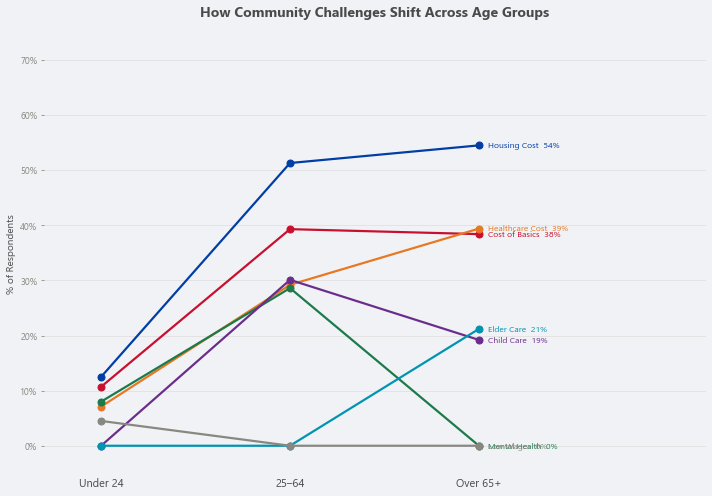

In [74]:
challenges = ['Housing Cost', 'Cost of Basics', 'Healthcare Cost',
              'Mental Health', 'Child Care', 'Elder Care', 'Low Wages']
under24 = [12.5, 10.7,  7.1,  8.0,  0.0,  0.0, 4.5]
mid64   = [51.3, 39.3, 29.2, 28.6, 30.1,  0.0, 0.0]
over65  = [54.5, 38.4, 39.4,  0.0, 19.2, 21.2, 0.0]

line_colors = [
    "#003DA5", "#C8102E", "#E87722",
    "#1B7A4A", "#6B2D8B", "#0093B2", "#888780"
]

age_labels = ["Under 24", "25–64", "Over 65+"]
x = [0, 1, 2]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for i, (challenge, color) in enumerate(zip(challenges, line_colors)):
    vals = [under24[i], mid64[i], over65[i]]

    ax.plot(x, vals,
            color=color, linewidth=2.2,
            marker="o", markersize=7,
            zorder=3, label=challenge)

    # Label at the end of each line (right side)
    ax.text(2.05, over65[i],
            f"{challenge}  {over65[i]:.0f}%",
            va="center", ha="left",
            fontsize=8.5, color=color)

# ── AXES STYLING ──────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(age_labels, fontsize=11, color=LABEL_COLOR)
ax.set_xlim(-0.3, 3.2)
ax.set_ylim(-5, 75)
ax.set_ylabel("% of Respondents", fontsize=10, color=LABEL_COLOR)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
ax.tick_params(axis="y", colors=SUB_COLOR, labelsize=9)
ax.tick_params(axis="x", length=0)
ax.yaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.xaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "How Community Challenges Shift Across Age Groups",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16
)

plt.tight_layout()
# plt.savefig("slide_age_slope.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
# print("Saved: slide_age_slope.png")

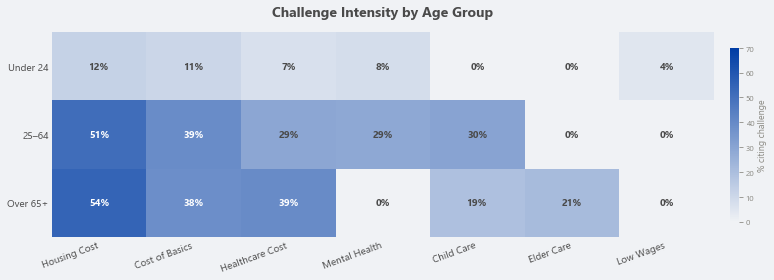

In [73]:
challenges = ['Housing Cost', 'Cost of Basics', 'Healthcare Cost',
              'Mental Health', 'Child Care', 'Elder Care', 'Low Wages']
age_labels = ["Under 24", "25–64", "Over 65+"]

# Rows = age groups, Cols = challenges
data = np.array([
    [12.5, 10.7,  7.1,  8.0,  0.0,  0.0, 4.5],  # Under 24
    [51.3, 39.3, 29.2, 28.6, 30.1,  0.0, 0.0],  # 25-64
    [54.5, 38.4, 39.4,  0.0, 19.2, 21.2, 0.0],  # Over 65+
])

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Custom colormap — white (0%) to UW blue (high %)
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("uw", ["#F0F2F5", "#003DA5"])

im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0, vmax=70)

# ── CELL LABELS ───────────────────────────────────────────────────────────────
for row in range(len(age_labels)):
    for col in range(len(challenges)):
        val = data[row, col]
        # Use white text on dark cells, dark text on light cells
        text_color = "white" if val > 35 else LABEL_COLOR
        ax.text(col, row, f"{val:.0f}%",
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color=text_color)

# ── AXES STYLING ──────────────────────────────────────────────────────────────
ax.set_xticks(range(len(challenges)))
ax.set_xticklabels(challenges, fontsize=10, color=LABEL_COLOR, rotation=20, ha="right")
ax.set_yticks(range(len(age_labels)))
ax.set_yticklabels(age_labels, fontsize=10, color=LABEL_COLOR)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
cbar.set_label("% citing challenge", fontsize=9, color=SUB_COLOR)
cbar.ax.tick_params(labelsize=8, colors=SUB_COLOR)
cbar.outline.set_visible(False)

ax.set_title(
    "Challenge Intensity by Age Group",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16
)

plt.tight_layout()
# plt.savefig("slide_age_heatmap.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
# print("Saved: slide_age_heatmap.png")

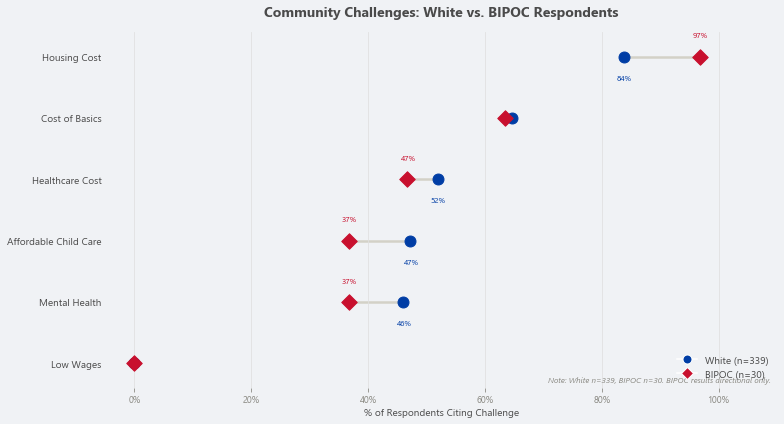

Saved: slide_race_dumbbell.png


In [67]:
challenges = ['Housing Cost', 'Cost of Basics', 'Healthcare Cost',
              'Affordable Child Care', 'Mental Health', 'Low Wages']
white = [83.8, 64.6, 51.9, 47.2, 46.0,  0.0]
bipoc = [96.7, 63.3, 46.7, 36.7, 36.7,  0.0]

# Sort by White value descending
pairs = sorted(zip(challenges, white, bipoc), key=lambda x: x[1])
challenges, white, bipoc = zip(*pairs)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

y_pos = range(len(challenges))

# Connecting line
for i, (w, b) in enumerate(zip(white, bipoc)):
    ax.plot([w, b], [i, i],
            color="#D3D1C7", linewidth=2.5, zorder=1)

# White dots — blue circles
ax.scatter(white, y_pos,
           color=BLUE_ACCENT, s=120,
           zorder=3, label="White")

# BIPOC dots — red diamonds
ax.scatter(bipoc, y_pos,
           color=RED_ACCENT, s=120,
           marker="D", zorder=3, label="BIPOC")

# Value labels — White below, BIPOC above
for i, (w, b) in enumerate(zip(white, bipoc)):
    if abs(w - b) < 5:
        continue
    offset = 0.28
    ax.text(w, i - offset, f"{w:.0f}%",
            ha="center", va="top",
            fontsize=8, color=BLUE_ACCENT)
    ax.text(b, i + offset, f"{b:.0f}%",
            ha="center", va="bottom",
            fontsize=8, color=RED_ACCENT)

# ── AXES STYLING ──────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(challenges, fontsize=10, color=LABEL_COLOR)
ax.set_xlabel("% of Respondents Citing Challenge", fontsize=10, color=LABEL_COLOR)
ax.set_xlim(-5, 110)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}%"))
ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax.tick_params(axis="y", length=0)
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Community Challenges: White vs. BIPOC Respondents",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16
)

# Sample size note
ax.text(0.99, 0.01,
        "Note: White n=339, BIPOC n=30. BIPOC results directional only.",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=8, color=SUB_COLOR, style="italic")

# ── LEGEND ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=BLUE_ACCENT,
           markersize=9, label="White (n=339)"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=RED_ACCENT,
           markersize=9, label="BIPOC (n=30)"),
]
leg = ax.legend(handles=legend_elements, loc="lower right", frameon=False, fontsize=10)
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

plt.tight_layout()
# plt.savefig("slide_race_dumbbell.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
# print("Saved: slide_race_dumbbell.png")

In [75]:
heard_data = {}
for group, subset in df_sm.groupby("alice_clean"):
    answered = subset[subset["feel_heard_clean"].notna()]
    total    = len(answered)
    unheard  = (answered["feel_heard_clean"] == "Unheard").sum()
    heard    = (answered["feel_heard_clean"] == "Heard").sum()
    heard_data[group] = {
        "Unheard": unheard / total * 100,
        "Heard":   heard   / total * 100,
        "n":       total
    }

print("── Heard vs Unheard by ALICE Status (respondents only) ──")
for group, vals in heard_data.items():
    print(f"\n  {group} (n={vals['n']})")
    print(f"    Unheard: {vals['Unheard']:.1f}%")
    print(f"    Heard:   {vals['Heard']:.1f}%")

── Heard vs Unheard by ALICE Status (respondents only) ──

  Above ALICE (n=627)
    Unheard: 79.6%
    Heard:   20.4%

  Below ALICE (n=221)
    Unheard: 58.8%
    Heard:   41.2%


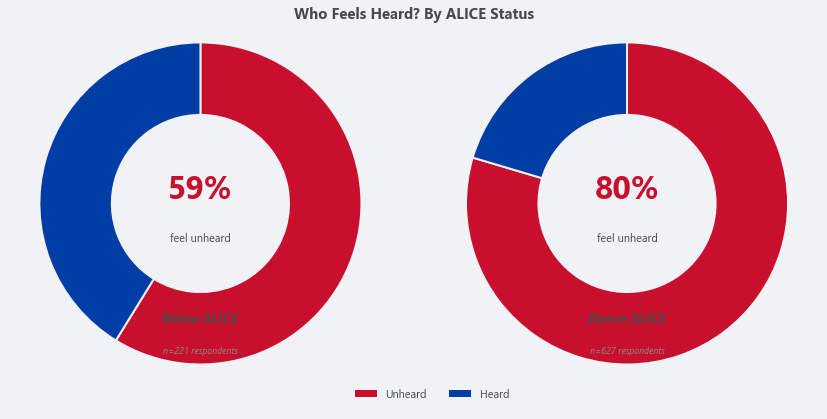

In [76]:
import matplotlib.patches as mpatches

groups  = ["Below ALICE", "Above ALICE"]
unheard = [58.8, 79.6]
heard   = [41.2, 20.4]
ns      = [221, 627]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)

fig.text(0.5, 0.97,
         "Who Feels Heard? By ALICE Status",
         ha="center", va="top",
         fontsize=15, fontweight="bold", color=LABEL_COLOR)

for ax, group, u, h, n in zip(axes, groups, unheard, heard, ns):
    ax.set_facecolor(BG_COLOR)

    # Donut slices — Unheard first so it sits at top
    wedges, _ = ax.pie(
        [u, h],
        colors=[RED_ACCENT, BLUE_ACCENT],
        startangle=90,
        wedgeprops=dict(width=0.45, edgecolor=BG_COLOR, linewidth=2),
        counterclock=False
    )

    # Center text — big % number
    ax.text(0, 0.08, f"{u:.0f}%",
            ha="center", va="center",
            fontsize=32, fontweight="bold",
            color=RED_ACCENT)

    ax.text(0, -0.22, "feel unheard",
            ha="center", va="center",
            fontsize=11, color=LABEL_COLOR)

    # Group label below donut
    ax.text(0, -0.72, group,
            ha="center", va="center",
            fontsize=13, fontweight="bold", color=LABEL_COLOR)

    ax.text(0, -0.92, f"n={n} respondents",
            ha="center", va="center",
            fontsize=9, color=SUB_COLOR, style="italic")

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.1, 1.1)
    ax.axis("off")

# Shared legend
legend_elements = [
    mpatches.Patch(facecolor=RED_ACCENT, label="Unheard"),
    mpatches.Patch(facecolor=BLUE_ACCENT, label="Heard"),
]
leg = fig.legend(handles=legend_elements,
                 loc="lower center", ncol=2,
                 frameon=False, fontsize=11,
                 bbox_to_anchor=(0.5, 0.02))
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("heard_alice.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

In [79]:
# Filter to only those who want to get involved
df_involved = df_sm[df_sm["want_involvement_clean"] == "Yes"]
print(f"Total who want to get involved: {len(df_involved)}")

involve_cols = [c for c in df_sm.columns if c.startswith("how_involvement_") 
                and "clean" not in c]

print("\n── Engagement Preferences (among those who want to get involved) ──")
total = len(df_involved)
for col in involve_cols:
    label = col.replace("how_involvement_", "")
    count = pd.to_numeric(df_involved[col], errors="coerce").sum()
    pct   = count / total * 100
    print(f"  {label}: {pct:.1f}%  (n={int(count)})")

print("\n── By ALICE Status ──")
for group, subset in df_involved.groupby("alice_clean"):
    n = len(subset)
    print(f"\n  {group} (n={n})")
    for col in involve_cols:
        label = col.replace("how_involvement_", "")
        count = pd.to_numeric(subset[col], errors="coerce").sum()
        pct   = count / n * 100
        print(f"    {label}: {pct:.1f}%  (n={int(count)})")

Total who want to get involved: 99

── Engagement Preferences (among those who want to get involved) ──
  Connect: 5.1%  (n=5)
  Donate: 10.1%  (n=10)
  Join Group: 40.4%  (n=40)
  Share Story: 22.2%  (n=22)
  Speak Up: 40.4%  (n=40)
  Volunteer: 57.6%  (n=57)

── By ALICE Status ──

  Above ALICE (n=58)
    Connect: 5.2%  (n=3)
    Donate: 17.2%  (n=10)
    Join Group: 36.2%  (n=21)
    Share Story: 19.0%  (n=11)
    Speak Up: 39.7%  (n=23)
    Volunteer: 58.6%  (n=34)

  Below ALICE (n=40)
    Connect: 5.0%  (n=2)
    Donate: 0.0%  (n=0)
    Join Group: 45.0%  (n=18)
    Share Story: 27.5%  (n=11)
    Speak Up: 40.0%  (n=16)
    Volunteer: 55.0%  (n=22)


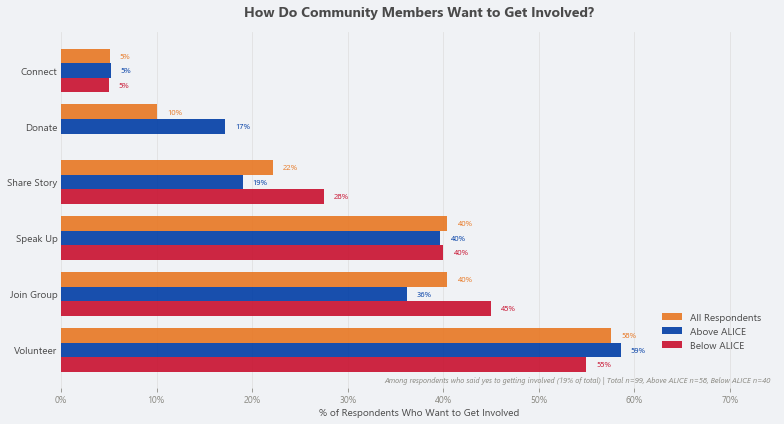

In [83]:
# ── DATA ──────────────────────────────────────────────────────────────────────
labels  = ["Volunteer", "Join Group", "Speak Up", "Share Story", "Donate", "Connect"]
overall = [57.6, 40.4, 40.4, 22.2, 10.1, 5.1]
above   = [58.6, 36.2, 39.7, 19.0, 17.2, 5.2]
below   = [55.0, 45.0, 40.0, 27.5,  0.0, 5.0]

# Sort by overall descending — already sorted above
y_pos = np.arange(len(labels))
bar_h = 0.26

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Three horizontal bars per category
bars_o = ax.barh(y_pos + bar_h,   overall, bar_h, color=AMBER_ACCENT, alpha=0.9, label="All Respondents", zorder=2)
bars_a = ax.barh(y_pos,           above,   bar_h, color=BLUE_ACCENT,  alpha=0.9, label="Above ALICE",     zorder=2)
bars_b = ax.barh(y_pos - bar_h,   below,   bar_h, color=RED_ACCENT,   alpha=0.9, label="Below ALICE",     zorder=2)

# Value labels
for bars, vals, color in [(bars_o, overall, AMBER_ACCENT),
                           (bars_a, above,   BLUE_ACCENT),
                           (bars_b, below,   RED_ACCENT)]:
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                    f"{val:.0f}%",
                    va="center", ha="left",
                    fontsize=8, color=color)

# ── AXES STYLING ──────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10, color=LABEL_COLOR)
ax.set_xlabel("% of Respondents Who Want to Get Involved", fontsize=10, color=LABEL_COLOR)
ax.set_xlim(0, 75)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax.tick_params(axis="y", length=0)
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "How Do Community Members Want to Get Involved?",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16
)

# Sample size note
ax.text(0.99, 0.01,
        "Among respondents who said yes to getting involved (19% of total) | Total n=99, Above ALICE n=58, Below ALICE n=40",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=7.5, color=SUB_COLOR, style="italic")

# ── LEGEND ────────────────────────────────────────────────────────────────────
leg = ax.legend(frameon=False, fontsize=10, loc="lower right",
                bbox_to_anchor=(0.99, 0.08))
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

plt.tight_layout()
# plt.savefig("slide_engagement.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

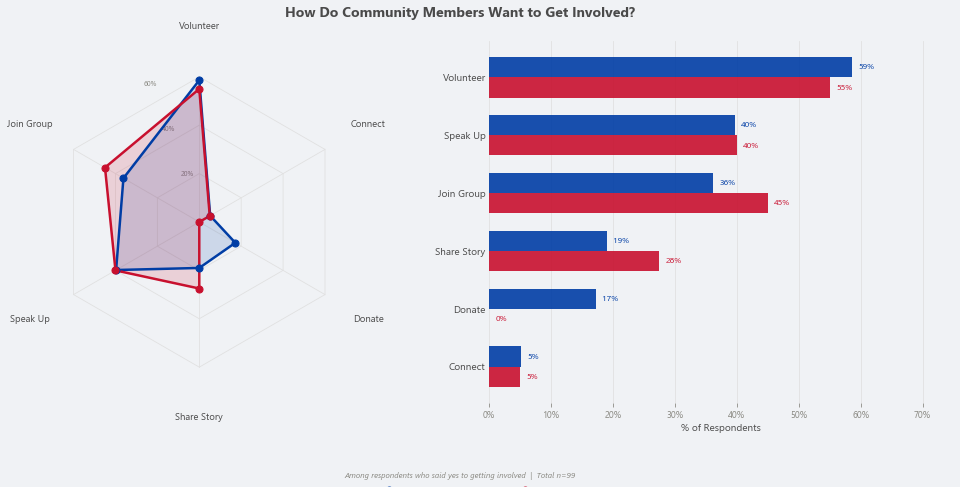

In [98]:
# ── DATA ──────────────────────────────────────────────────────────────────────
labels  = ["Volunteer", "Join Group", "Speak Up", "Share Story", "Donate", "Connect"]
above   = [58.6, 36.2, 39.7, 19.0, 17.2, 5.2]
below   = [55.0, 45.0, 40.0, 27.5,  0.0, 5.0]

above_closed = above + [above[0]]
below_closed = below + [below[0]]
n      = len(labels)
angles = [i * 2 * np.pi / n for i in range(n)] + [0]

# ── FIGURE: 1 row, 2 panels ───────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)

ax_radar = fig.add_subplot(121, polar=True)
ax_bar   = fig.add_subplot(122)

fig.suptitle("How Do Community Members Want to Get Involved?",
             fontsize=14, fontweight="bold", color=LABEL_COLOR, y=1.01)

# ── LEFT: RADAR ───────────────────────────────────────────────────────────────
ax_radar.set_facecolor(BG_COLOR)
ax_radar.yaxis.grid(False)
ax_radar.xaxis.grid(False)
for spine in ax_radar.spines.values():
    spine.set_visible(False)

for r in [20, 40, 60]:
    ax_radar.plot(angles, [r] * len(angles),
                  color="#E0E0E0", linewidth=0.8, zorder=0)
for angle in angles[:-1]:
    ax_radar.plot([angle, angle], [0, 60],
                  color="#E0E0E0", linewidth=0.8, zorder=0)

ax_radar.plot(angles, above_closed, color=BLUE_ACCENT, linewidth=2.5, zorder=3)
ax_radar.fill(angles, above_closed, color=BLUE_ACCENT, alpha=0.15, zorder=2)
ax_radar.plot(angles, below_closed, color=RED_ACCENT,  linewidth=2.5, zorder=3)
ax_radar.fill(angles, below_closed, color=RED_ACCENT,  alpha=0.15, zorder=2)
ax_radar.scatter(angles[:-1], above, color=BLUE_ACCENT, s=50, zorder=4)
ax_radar.scatter(angles[:-1], below, color=RED_ACCENT,  s=50, zorder=4)

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels, fontsize=9.5, color=LABEL_COLOR)
ax_radar.set_yticks([20, 40, 60])
ax_radar.set_yticklabels(["20%", "40%", "60%"], fontsize=7, color=SUB_COLOR)
ax_radar.set_ylim(0, 75)

# ── RIGHT: HORIZONTAL BAR ─────────────────────────────────────────────────────
ax_bar.set_facecolor(BG_COLOR)

y_pos  = np.arange(len(labels))
bar_h  = 0.35

# Sort by above value for cleaner bar chart
order  = sorted(range(len(labels)), key=lambda i: above[i])
labels_sorted = [labels[i] for i in order]
above_sorted  = [above[i]  for i in order]
below_sorted  = [below[i]  for i in order]

bars_a = ax_bar.barh(y_pos + bar_h/2, above_sorted, bar_h,
                     color=BLUE_ACCENT, alpha=0.9, zorder=2)
bars_b = ax_bar.barh(y_pos - bar_h/2, below_sorted, bar_h,
                     color=RED_ACCENT,  alpha=0.9, zorder=2)

# Value labels
for bar, val in zip(bars_a, above_sorted):
    if val > 0:
        ax_bar.text(val + 1, bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", va="center", fontsize=8.5, color=BLUE_ACCENT)
for bar, val in zip(bars_b, below_sorted):
    ax_bar.text(val + 1, bar.get_y() + bar.get_height()/2,
                f"{val:.0f}%" if val > 0 else "0%",
                va="center", fontsize=8.5, color=RED_ACCENT)

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(labels_sorted, fontsize=10, color=LABEL_COLOR)
ax_bar.set_xlabel("% of Respondents", fontsize=10, color=LABEL_COLOR)
ax_bar.set_xlim(0, 75)
ax_bar.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
ax_bar.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax_bar.tick_params(axis="y", length=0)
ax_bar.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax_bar.yaxis.grid(False)
for spine in ax_bar.spines.values():
    spine.set_visible(False)

# ── SHARED LEGEND ─────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=BLUE_ACCENT, linewidth=2.5,
           marker="o", markersize=7, label="Above ALICE (n=58)"),
    Line2D([0], [0], color=RED_ACCENT,  linewidth=2.5,
           marker="o", markersize=7, label="Below ALICE (n=40)"),
]
leg = fig.legend(handles=legend_elements,
                 loc="lower center", ncol=2,
                 frameon=False, fontsize=10,
                 bbox_to_anchor=(0.5, -0.04))
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

fig.text(0.5, -0.08,
         "Among respondents who said yes to getting involved  |  Total n=99",
         ha="center", fontsize=8, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("slide_engagement_combined.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

In [105]:
df_sm = df_sm.merge(
    community_df[['uid', 'community_fine', 'community_super']], 
    on='uid', 
    how='left'
)

print(df_sm['community_super'].value_counts())
print(f"df_sm shape: {df_sm.shape}")

Town of Residence     98
BIPOC                 33
Other                 29
Women                 22
Older Adults (+65)    20
LGBTQ+                19
Immigrant             14
Youth (under 18)      13
Parents                9
Recovery Community     8
ALICE                  2
Single Mothers         2
Hispanic               1
White                  1
Name: community_super, dtype: int64
df_sm shape: (1702, 131)


Communities included:
Town of Residence     98
BIPOC                 33
Women                 22
Older Adults (+65)    20
LGBTQ+                19
Immigrant             14
Youth (under 18)      13
Parents                9
Recovery Community     8
ALICE                  2
Single Mothers         2
Hispanic               1
White                  1
Name: community_super, dtype: int64


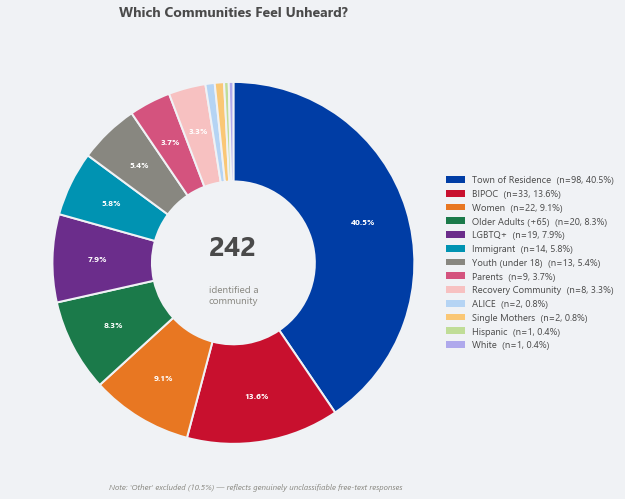

Saved: slide_unheard_communities.png


In [108]:
# ── DATA from community_super, excluding Other ─────────────────────────────────
community_counts = df_sm["community_super"].value_counts()
community_counts = community_counts.drop("Other", errors="ignore")

print("Communities included:")
print(community_counts)

labels = community_counts.index.tolist()
sizes  = community_counts.values.tolist()
total  = sum(sizes)

# ── COLORS ────────────────────────────────────────────────────────────────────
colors = [
    "#003DA5",  # Town of Residence
    "#C8102E",  # BIPOC
    "#E87722",  # Women
    "#1B7A4A",  # Older Adults
    "#6B2D8B",  # LGBTQ+
    "#0093B2",  # Immigrant
    "#888780",  # Youth
    "#D4537E",  # Parents
    "#F7C1C1",  # Recovery Community
    "#B5D4F4",  # ALICE
    "#FAC775",  # Single Mothers
    "#C0DD97",  # Hispanic
    "#AFA9EC",  # White
][:len(labels)]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.55, edgecolor=BG_COLOR, linewidth=2),
    pctdistance=0.75,
)

for autotext in autotexts:
    autotext.set_fontsize(8.5)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

# Center text
ax.text(0, 0.08, f"{total}",
        ha="center", va="center",
        fontsize=28, fontweight="bold", color=LABEL_COLOR)
ax.text(0, -0.18, "identified a\ncommunity",
        ha="center", va="center",
        fontsize=10, color=SUB_COLOR, linespacing=1.4)

# ── LEGEND ────────────────────────────────────────────────────────────────────
legend_labels = [f"{l}  (n={s}, {s/total*100:.1f}%)"
                 for l, s in zip(labels, sizes)]

patches = [plt.matplotlib.patches.Patch(facecolor=c, label=l)
           for c, l in zip(colors, legend_labels)]

leg = ax.legend(handles=patches,
                loc="center left",
                bbox_to_anchor=(0.95, 0.5),
                frameon=False,
                fontsize=9.5)
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

ax.set_title(
    "Which Communities Feel Unheard?",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=20
)

fig.text(0.5, 0.02,
         "Note: 'Other' excluded (10.5%) — reflects genuinely unclassifiable free-text responses",
         ha="center", fontsize=8, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("slide_unheard_communities.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: slide_unheard_communities.png")

C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 10003 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 10007 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 10003 missing from current font.
  font.set_text(s, 0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 10007 missing from current font.
  font.set_text(s, 0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:176: RuntimeWarning: Glyph 10003 missing from current font.
  font.load_char(ord(s), flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:176: RuntimeWarning: Glyph 10007 missing from curr

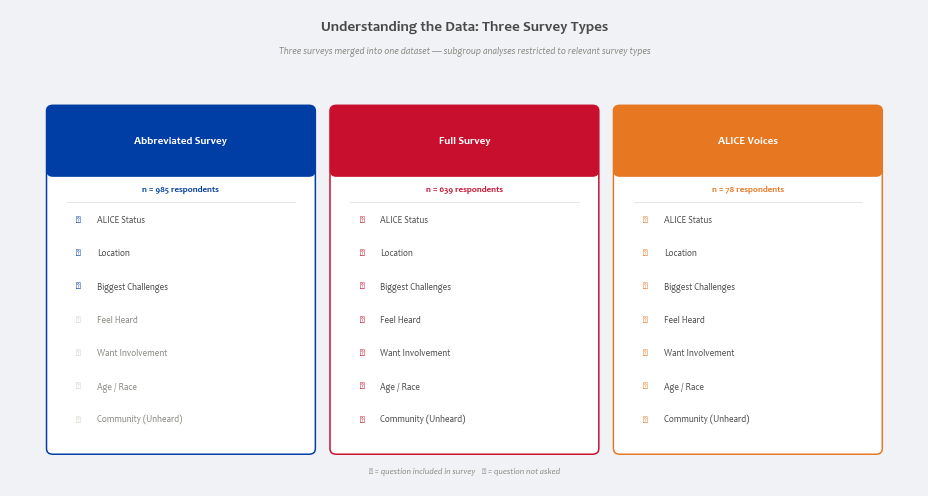

Saved: slide_survey_overview.png


In [5]:
plt.rcParams["font.family"] = "Candara"

# ── SURVEY GROUPINGS ──────────────────────────────────────────────────────────
abbreviated_types = ["3Q", "Convo CheckIn", "GiveAtWork", "United We Can"]
full_types        = ["Full Survey"]
alice_types       = ["Community Impact"]

n_abbreviated = df_sm[df_sm["survey_type"].isin(abbreviated_types)].shape[0]
n_full        = df_sm[df_sm["survey_type"].isin(full_types)].shape[0]
n_alice       = df_sm[df_sm["survey_type"].isin(alice_types)].shape[0]

surveys = [
    {
        "name":      "Abbreviated Survey",
        "n":         n_abbreviated,
        "color":     BLUE_ACCENT,
        "questions": [
            ("ALICE Status",        True),
            ("Location",            True),
            ("Biggest Challenges",  True),
            ("Feel Heard",          False),
            ("Want Involvement",    False),
            ("Age / Race",          False),
            ("Community (Unheard)", False),
        ]
    },
    {
        "name":      "Full Survey",
        "n":         n_full,
        "color":     RED_ACCENT,
        "questions": [
            ("ALICE Status",        True),
            ("Location",            True),
            ("Biggest Challenges",  True),
            ("Feel Heard",          True),
            ("Want Involvement",    True),
            ("Age / Race",          True),
            ("Community (Unheard)", True),
        ]
    },
    {
        "name":      "ALICE Voices",
        "n":         n_alice,
        "color":     AMBER_ACCENT,
        "questions": [
            ("ALICE Status",        True),
            ("Location",            True),
            ("Biggest Challenges",  True),
            ("Feel Heard",          True),
            ("Want Involvement",    True),
            ("Age / Race",          True),
            ("Community (Unheard)", True),
        ]
    },
]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)

# Title
ax.text(5, 5.75,
        "Understanding the Data: Three Survey Types",
        ha="center", va="center",
        fontsize=15, fontweight="bold", color=LABEL_COLOR)

ax.text(5, 5.45,
        "Three surveys merged into one dataset — subgroup analyses restricted to relevant survey types",
        ha="center", va="center",
        fontsize=9.5, color=SUB_COLOR, style="italic")

# ── CARDS ─────────────────────────────────────────────────────────────────────
card_w  = 2.8
card_h  = 4.2
gap     = 0.3
total_w = 3 * card_w + 2 * gap
start_x = (10 - total_w) / 2
card_y  = 0.5

for i, survey in enumerate(surveys):
    x     = start_x + i * (card_w + gap)
    color = survey["color"]

    # White card
    card = mpatches.FancyBboxPatch(
        (x, card_y), card_w, card_h,
        boxstyle="round,pad=0.07",
        linewidth=1.5, edgecolor=color,
        facecolor="#FFFFFF", zorder=2
    )
    ax.add_patch(card)

    # Colored header
    bar_h = 0.75
    bar = mpatches.FancyBboxPatch(
        (x, card_y + card_h - bar_h), card_w, bar_h,
        boxstyle="round,pad=0.07",
        linewidth=0, facecolor=color, zorder=3
    )
    ax.add_patch(bar)

    # Square off bottom of header
    sq = mpatches.FancyBboxPatch(
        (x, card_y + card_h - bar_h), card_w, bar_h * 0.45,
        boxstyle="round,pad=0.0",
        linewidth=0, facecolor=color, zorder=3
    )
    ax.add_patch(sq)

    # Survey name
    ax.text(x + card_w / 2, card_y + card_h - bar_h / 2,
            survey["name"],
            ha="center", va="center",
            fontsize=11, fontweight="bold", color="white",
            zorder=4)

    # N respondents
    ax.text(x + card_w / 2, card_y + card_h - bar_h - 0.22,
            f"n = {survey['n']:,} respondents",
            ha="center", va="center",
            fontsize=9, fontweight="bold", color=color,
            zorder=4)

    # Divider
    ax.plot([x + 0.15, x + card_w - 0.15],
            [card_y + card_h - bar_h - 0.38,
             card_y + card_h - bar_h - 0.38],
            color="#E0E0E0", linewidth=0.8, zorder=3)

    # Question rows
    n_q   = len(survey["questions"])
    row_h = (card_h - bar_h - 0.55) / n_q

    for j, (q_label, covered) in enumerate(survey["questions"]):
        y_pos = card_y + card_h - bar_h - 0.6 - j * row_h

        symbol    = "✓" if covered else "✗"
        sym_color = color if covered else "#D3D1C7"
        txt_color = LABEL_COLOR if covered else SUB_COLOR

        ax.text(x + 0.28, y_pos, symbol,
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color=sym_color, zorder=4)

        ax.text(x + 0.48, y_pos, q_label,
                ha="left", va="center",
                fontsize=9, color=txt_color, zorder=4)

# Footer
ax.text(5, 0.22,
        "✓ = question included in survey    ✗ = question not asked",
        ha="center", va="center",
        fontsize=8.5, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("slide_survey_overview.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: slide_survey_overview.png")

C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 10003 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 10007 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 10003 missing from current font.
  font.set_text(s, 0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 10007 missing from current font.
  font.set_text(s, 0, flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:176: RuntimeWarning: Glyph 10003 missing from current font.
  font.load_char(ord(s), flags=flags)
C:\Users\marzo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:176: RuntimeWarning: Glyph 10007 missing from curr

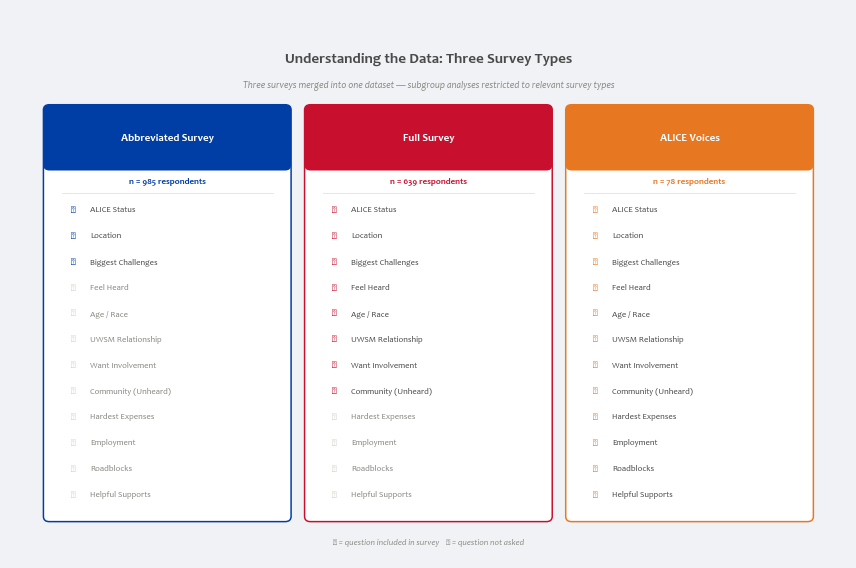

Saved: slide_survey_overview.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["font.family"] = "Candara"

# ── SURVEY GROUPINGS ──────────────────────────────────────────────────────────
abbreviated_types = ["3Q", "Convo CheckIn", "GiveAtWork", "United We Can"]
full_types        = ["Full Survey"]
alice_types       = ["Community Impact"]

n_abbreviated = df_sm[df_sm["survey_type"].isin(abbreviated_types)].shape[0]
n_full        = df_sm[df_sm["survey_type"].isin(full_types)].shape[0]
n_alice       = df_sm[df_sm["survey_type"].isin(alice_types)].shape[0]

surveys = [
    {
        "name":  "Abbreviated Survey",
        "n":     n_abbreviated,
        "color": BLUE_ACCENT,
        "questions": [
            ("ALICE Status",        True),
            ("Location",            True),
            ("Biggest Challenges",  True),
            ("Feel Heard",          False),
            ("Age / Race",          False),
            ("UWSM Relationship",   False),
            ("Want Involvement",    False),
            ("Community (Unheard)", False),
            ("Hardest Expenses",    False),
            ("Employment",          False),
            ("Roadblocks",          False),
            ("Helpful Supports",    False),
        ]
    },
    {
        "name":  "Full Survey",
        "n":     n_full,
        "color": RED_ACCENT,
        "questions": [
            ("ALICE Status",        True),
            ("Location",            True),
            ("Biggest Challenges",  True),
            ("Feel Heard",          True),
            ("Age / Race",          True),
            ("UWSM Relationship",   True),
            ("Want Involvement",    True),
            ("Community (Unheard)", True),
            ("Hardest Expenses",    False),
            ("Employment",          False),
            ("Roadblocks",          False),
            ("Helpful Supports",    False),
        ]
    },
    {
        "name":  "ALICE Voices",
        "n":     n_alice,
        "color": AMBER_ACCENT,
        "questions": [
            ("ALICE Status",        True),
            ("Location",            True),
            ("Biggest Challenges",  True),
            ("Feel Heard",          True),
            ("Age / Race",          True),
            ("UWSM Relationship",   True),
            ("Want Involvement",    True),
            ("Community (Unheard)", True),
            ("Hardest Expenses",    True),
            ("Employment",          True),
            ("Roadblocks",          True),
            ("Helpful Supports",    True),
        ]
    },
]

# ── LAYOUT CONSTANTS ──────────────────────────────────────────────────────────
card_w   = 2.8
card_h   = 5.5
gap      = 0.3
total_w  = 3 * card_w + 2 * gap
start_x  = (10 - total_w) / 2
card_y   = 0.6    # bottom of cards
title_y  = 6.8    # title sits well above cards
sub_y    = 6.45   # subtitle just below title
canvas_h = 7.5    # total canvas height

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, canvas_h)

# Title
ax.text(5, title_y,
        "Understanding the Data: Three Survey Types",
        ha="center", va="center",
        fontsize=15, fontweight="bold", color=LABEL_COLOR)

ax.text(5, sub_y,
        "Three surveys merged into one dataset — subgroup analyses restricted to relevant survey types",
        ha="center", va="center",
        fontsize=9.5, color=SUB_COLOR, style="italic")

# ── CARDS ─────────────────────────────────────────────────────────────────────
for i, survey in enumerate(surveys):
    x     = start_x + i * (card_w + gap)
    color = survey["color"]

    # White card with colored border
    card = mpatches.FancyBboxPatch(
        (x, card_y), card_w, card_h,
        boxstyle="round,pad=0.07",
        linewidth=1.5, edgecolor=color,
        facecolor="#FFFFFF", zorder=2
    )
    ax.add_patch(card)

    # Colored header
    bar_h = 0.75
    bar = mpatches.FancyBboxPatch(
        (x, card_y + card_h - bar_h), card_w, bar_h,
        boxstyle="round,pad=0.07",
        linewidth=0, facecolor=color, zorder=3
    )
    ax.add_patch(bar)

    # Square off bottom of header
    sq = mpatches.FancyBboxPatch(
        (x, card_y + card_h - bar_h), card_w, bar_h * 0.45,
        boxstyle="round,pad=0.0",
        linewidth=0, facecolor=color, zorder=3
    )
    ax.add_patch(sq)

    # Survey name
    ax.text(x + card_w / 2, card_y + card_h - bar_h / 2,
            survey["name"],
            ha="center", va="center",
            fontsize=11, fontweight="bold", color="white",
            zorder=4)

    # N respondents
    ax.text(x + card_w / 2, card_y + card_h - bar_h - 0.22,
            f"n = {survey['n']:,} respondents",
            ha="center", va="center",
            fontsize=9, fontweight="bold", color=color,
            zorder=4)

    # Divider
    ax.plot([x + 0.15, x + card_w - 0.15],
            [card_y + card_h - bar_h - 0.38,
             card_y + card_h - bar_h - 0.38],
            color="#E0E0E0", linewidth=0.8, zorder=3)

    # Question rows
    n_q   = len(survey["questions"])
    row_h = (card_h - bar_h - 0.55) / n_q

    for j, (q_label, covered) in enumerate(survey["questions"]):
        y_pos = card_y + card_h - bar_h - 0.6 - j * row_h

        symbol    = "✓" if covered else "✗"
        sym_color = color if covered else "#D3D1C7"
        txt_color = LABEL_COLOR if covered else SUB_COLOR

        ax.text(x + 0.28, y_pos, symbol,
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color=sym_color, zorder=4)

        ax.text(x + 0.48, y_pos, q_label,
                ha="left", va="center",
                fontsize=8.5, color=txt_color, zorder=4)

# Footer
ax.text(5, 0.25,
        "✓ = question included in survey    ✗ = question not asked",
        ha="center", va="center",
        fontsize=8.5, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("slide_survey_overview.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: slide_survey_overview.png")

In [122]:
df_model = df_sm[df_sm["alice_clean"].notna()].copy()

# Encode target: Below ALICE = 1, Above ALICE = 0
df_model["target"] = (df_model["alice_clean"] == "Below ALICE").astype(int)

print(f"Total samples: {len(df_model)}")
print(f"Below ALICE (1): {df_model['target'].sum()} ({df_model['target'].mean()*100:.1f}%)")
print(f"Above ALICE (0): {(df_model['target']==0).sum()} ({(df_model['target']==0).mean()*100:.1f}%)")

Total samples: 1686
Below ALICE (1): 509 (30.2%)
Above ALICE (0): 1177 (69.8%)


In [14]:
!pip install geopandas shapely

  Using cached geopandas-0.10.2-py2.py3-none-any.whl (1.0 MB)
  Attempting uninstall: click
    Found existing installation: Click 7.0
    Uninstalling Click-7.0:
      Successfully uninstalled Click-7.0


Loading county shapefile...
Maine counties loaded: 16
['Androscoggin', 'Sagadahoc', 'Washington', 'Waldo', 'York', 'Penobscot', 'Kennebec', 'Oxford', 'Piscataquis', 'Lincoln', 'Cumberland', 'Hancock', 'Knox', 'Franklin', 'Aroostook', 'Somerset']


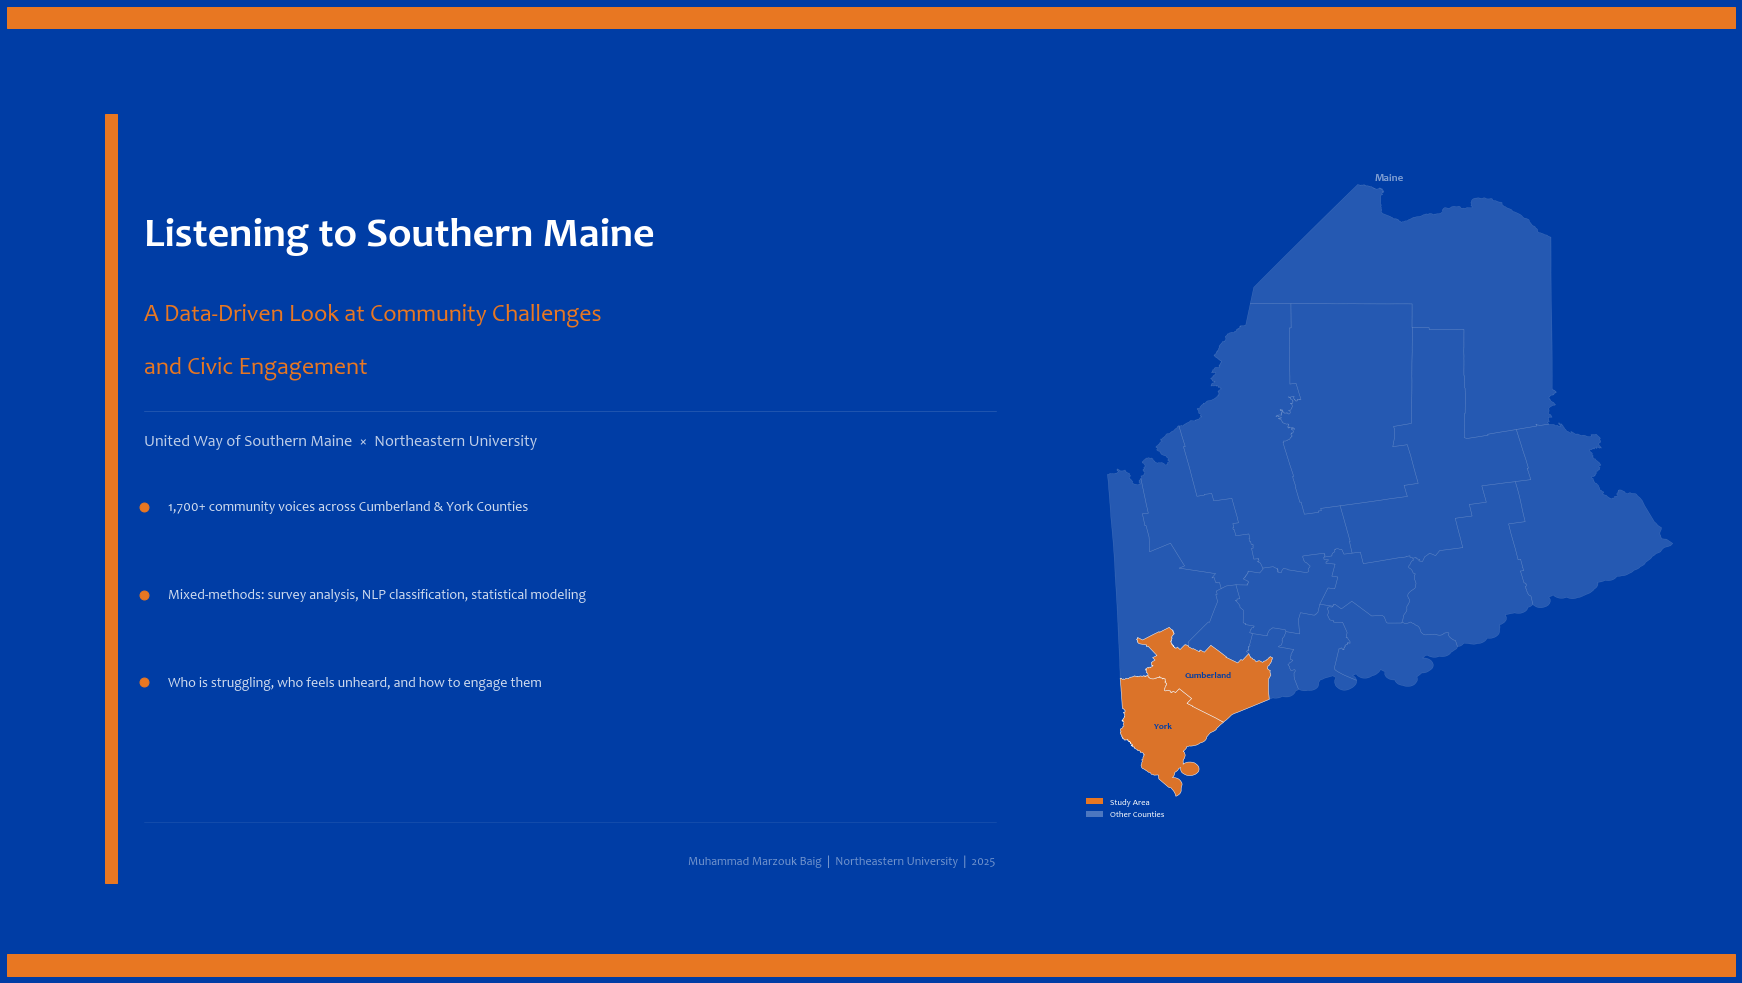

Saved: slide1_title_map.svg


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np

plt.rcParams["font.family"] = "Candara"

# ── LOAD MAINE COUNTIES ───────────────────────────────────────────────────────
print("Loading county shapefile...")
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip"
)
maine = counties[counties["STATEFP"] == "23"].copy()
maine = maine.to_crs(epsg=4326)

highlighted = ["Cumberland", "York"]
maine["color"] = maine["NAME"].apply(
    lambda n: AMBER_ACCENT if n in highlighted else "#FFFFFF"
)
maine["alpha"] = maine["NAME"].apply(
    lambda n: 0.95 if n in highlighted else 0.15
)

print(f"Maine counties loaded: {len(maine)}")
print(maine["NAME"].tolist())

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 13.5))
fig.patch.set_facecolor(BLUE_ACCENT)

# Text panel — left 60%
ax_text = fig.add_axes([0.04, 0.05, 0.56, 0.90])
ax_text.set_facecolor(BLUE_ACCENT)
ax_text.axis("off")
ax_text.set_xlim(0, 10)
ax_text.set_ylim(0, 10)

# Map panel — right 35%
ax_map = fig.add_axes([0.62, 0.05, 0.36, 0.90])
ax_map.set_facecolor(BLUE_ACCENT)
ax_map.axis("off")

# ── AMBER TOP + BOTTOM BARS ───────────────────────────────────────────────────
for y in [0, 0.975]:
    fig.add_artist(mpatches.Rectangle(
        (0, y), 1, 0.022,
        transform=fig.transFigure,
        color=AMBER_ACCENT, zorder=10
    ))

# ── LEFT ACCENT BAR ───────────────────────────────────────────────────────────
ax_text.add_patch(mpatches.Rectangle(
    (0.3, 0.5), 0.12, 8.8,
    color=AMBER_ACCENT, zorder=3
))

# ── TITLE ─────────────────────────────────────────────────────────────────────
ax_text.text(0.7, 7.9,
             "Listening to Southern Maine",
             ha="left", va="center",
             fontsize=42, fontweight="bold", color="white", zorder=4)

ax_text.text(0.7, 7.0,
             "A Data-Driven Look at Community Challenges",
             ha="left", va="center",
             fontsize=24, color=AMBER_ACCENT, zorder=4)

ax_text.text(0.7, 6.4,
             "and Civic Engagement",
             ha="left", va="center",
             fontsize=24, color=AMBER_ACCENT, zorder=4)

# Divider
ax_text.plot([0.7, 9.5], [5.9, 5.9],
             color="white", linewidth=0.6, alpha=0.2, zorder=3)

ax_text.text(0.7, 5.55,
             "United Way of Southern Maine  ×  Northeastern University",
             ha="left", va="center",
             fontsize=16, color="white", alpha=0.75, zorder=4)

# Bullets
bullets = [
    "1,700+ community voices across Cumberland & York Counties",
    "Mixed-methods: survey analysis, NLP classification, statistical modeling",
    "Who is struggling, who feels unheard, and how to engage them",
]
for i, bullet in enumerate(bullets):
    y = 4.7 - i * 1.0
    ax_text.scatter(0.7, y + 0.1, color=AMBER_ACCENT, s=80, zorder=5)
    ax_text.text(0.95, y + 0.1, bullet,
                 ha="left", va="center",
                 fontsize=14, color="white", alpha=0.82, zorder=4)

# Bottom name
ax_text.plot([0.7, 9.5], [1.2, 1.2],
             color="white", linewidth=0.5, alpha=0.15, zorder=3)
ax_text.text(9.5, 0.75,
             "Muhammad Marzouk Baig  |  Northeastern University  |  2025",
             ha="right", va="center",
             fontsize=12, color="white", alpha=0.45, zorder=4)

# ── DRAW MAP ──────────────────────────────────────────────────────────────────
for _, row in maine.iterrows():
    color = row["color"]
    alpha = row["alpha"]
    gpd.GeoSeries([row.geometry]).plot(
        ax=ax_map,
        color=color,
        alpha=alpha,
        edgecolor="white",
        linewidth=0.5
    )

# Labels for highlighted counties
for _, row in maine[maine["NAME"].isin(highlighted)].iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax_map.text(cx, cy, row["NAME"],
                ha="center", va="center",
                fontsize=9, fontweight="bold",
                color=BLUE_ACCENT, zorder=5)

# Maine title
ax_map.text(0.5, 0.97, "Maine", transform=ax_map.transAxes,
            ha="center", va="top",
            fontsize=11, color="white", alpha=0.5,
            fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=AMBER_ACCENT, label="Study Area"),
    Patch(facecolor="white", alpha=0.3, label="Other Counties"),
]
leg = ax_map.legend(handles=legend_elements,
                    loc="lower left", frameon=False,
                    fontsize=8.5)
for text in leg.get_texts():
    text.set_color("white")

plt.savefig("slide1_title_map.png", dpi=300,
            bbox_inches="tight", facecolor=BLUE_ACCENT)
plt.show()
print("Saved: slide1_title_map.svg")

In [124]:
# ── STEP 2: FEATURE SET ───────────────────────────────────────────────────────
# All challenge columns except None and Other
challenge_cols = [c for c in df_sm.columns
                  if c.startswith("biggest_challenge_")
                  and "None" not in c
                  and "Other" not in c
                  and c != "biggest_challenge_clean"] 

print(f"\nNumber of challenge features: {len(challenge_cols)}")

# Convert to numeric
X = df_model[challenge_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_model["target"]

# Clean feature names for display
feature_names = [c.replace("biggest_challenge_", "").replace("_", " ")
                 for c in challenge_cols]
print(feature_names)


Number of challenge features: 24
['Affordable Child Care Access', 'Affordable Elder Care Access', 'Affordable Housing Availability', 'Behavioral Health', 'Climate Impacts', 'Cost of Basics', 'Domestic Violence', 'Education Access', 'Food Access', 'Gas Costs', 'Healthcare Cost', 'Housing Cost', 'Immigration Enforcement', 'Job Instability', 'Lack of in Home Support', 'Language Access', 'Low Wages', 'Mental Health', 'Political Division', 'Rent Increases', 'Rising Taxes', 'Social Isolation', 'Transportation', 'Welfare Dependence']



── Cross Validation Results (Stratified 5-Fold) ──

── Decision Tree (max_depth=3) ──
  Accuracy:  0.547 ± 0.070
  Precision: 0.360 ± 0.045
  Recall:    0.601 ± 0.117
  F1 Score:  0.443 ± 0.039

── Decision Tree (max_depth=4) ──
  Accuracy:  0.582 ± 0.084
  Precision: 0.381 ± 0.053
  Recall:    0.511 ± 0.141
  F1 Score:  0.421 ± 0.024

── Decision Tree (max_depth=5) ──
  Accuracy:  0.561 ± 0.044
  Precision: 0.355 ± 0.023
  Recall:    0.542 ± 0.087
  F1 Score:  0.425 ± 0.029

── Top 10 Most Important Challenges for Predicting ALICE Status ──
  1. Affordable Child Care Access: 0.233
  2. Affordable Elder Care Access: 0.183
  3. Cost of Basics: 0.148
  4. Food Access: 0.144
  5. Social Isolation: 0.101
  6. Healthcare Cost: 0.097
  7. Behavioral Health: 0.062
  8. Mental Health: 0.033
  9. Affordable Housing Availability: 0.000
  10. Climate Impacts: 0.000


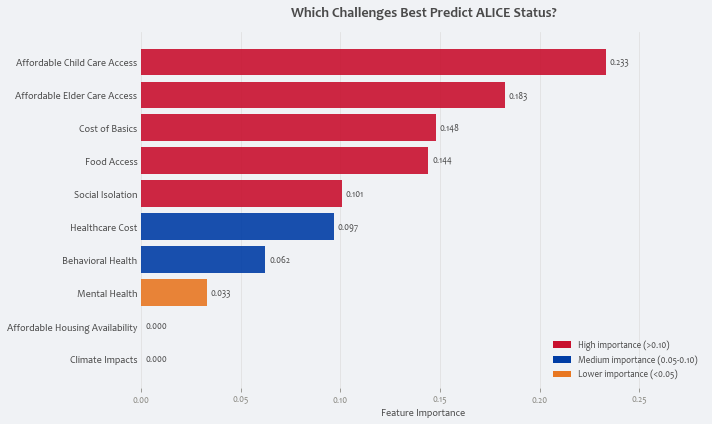

Saved: dt_alice_feature_importance.png


In [127]:

# ── STEP 3: CROSS VALIDATION ──────────────────────────────────────────────────
def run_cv(X, y, model_name, max_depth=4):
    clf = DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=max_depth,
        min_samples_leaf=10,
        random_state=42
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(
        clf, X, y, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
        return_train_score=False
    )
    print(f"\n── {model_name} (max_depth={max_depth}) ──")
    print(f"  Accuracy:  {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"  Precision: {scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}")
    print(f"  Recall:    {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}")
    print(f"  F1 Score:  {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    return scores

print("\n── Cross Validation Results (Stratified 5-Fold) ──")
scores_d3 = run_cv(X, y, "Decision Tree", max_depth=3)
scores_d4 = run_cv(X, y, "Decision Tree", max_depth=4)
scores_d5 = run_cv(X, y, "Decision Tree", max_depth=5)

# ── STEP 4: FIT FINAL TREE ────────────────────────────────────────────────────
# Use best depth from above for final visualization
best_clf = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)
best_clf.fit(X, y)

# ── STEP 5: FEATURE IMPORTANCE ────────────────────────────────────────────────
importances = best_clf.feature_importances_
indices     = np.argsort(importances)[::-1]

print("\n── Top 10 Most Important Challenges for Predicting ALICE Status ──")
for i in range(min(10, len(feature_names))):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.3f}")

# ── STEP 6: VISUALIZE FEATURE IMPORTANCE ─────────────────────────────────────
# Top 10 only for clarity
top_n = 10
top_indices = indices[:top_n]
top_names   = [feature_names[i] for i in top_indices]
top_imps    = importances[top_indices]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Color bars by importance tier
bar_colors = [RED_ACCENT if imp > 0.1 else
              BLUE_ACCENT if imp > 0.05 else
              AMBER_ACCENT for imp in top_imps]

bars = ax.barh(range(top_n), top_imps[::-1],
               color=bar_colors[::-1], alpha=0.9, zorder=2)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10, color=LABEL_COLOR)
ax.set_xlabel("Feature Importance", fontsize=10, color=LABEL_COLOR)
ax.set_title("Which Challenges Best Predict ALICE Status?",
             fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16)

for bar, val in zip(bars, top_imps[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9, color=LABEL_COLOR)

ax.set_xlim(0, max(top_imps) + 0.05)
ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax.tick_params(axis="y", length=0)
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED_ACCENT,   label="High importance (>0.10)"),
    Patch(facecolor=BLUE_ACCENT,  label="Medium importance (0.05-0.10)"),
    Patch(facecolor=AMBER_ACCENT, label="Lower importance (<0.05)"),
]
leg = ax.legend(handles=legend_elements, frameon=False,
                fontsize=9, loc="lower right")
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

plt.tight_layout()
plt.savefig("dt_alice_feature_importance.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: dt_alice_feature_importance.png")

Total samples: 1686
Below ALICE (1): 509 (30.2%)
Above ALICE (0): 1177 (69.8%)

── Logistic Regression: Cross Validation Results (Stratified 5-Fold) ──
  Accuracy:  0.556 ± 0.041
  Precision: 0.368 ± 0.024
  Recall:    0.649 ± 0.111
  F1 Score:  0.466 ± 0.041

── Odds Ratios (sorted) ──
  OR > 1 = increases odds of being Below ALICE
  OR < 1 = decreases odds of being Below ALICE

  Education Access                    OR=2.27  ↑ Below ALICE
  Gas Costs                           OR=2.13  ↑ Below ALICE
  Food Access                         OR=1.66  ↑ Below ALICE
  Transportation                      OR=1.39  ↑ Below ALICE
  Cost of Basics                      OR=1.37  ↑ Below ALICE
  Housing Cost                        OR=1.20  ↑ Below ALICE
  Low Wages                           OR=1.15  ↑ Below ALICE
  Mental Health                       OR=1.04  ↑ Below ALICE
  Welfare Dependence                  OR=0.96  ↓ Above ALICE
  Lack of in Home Support             OR=0.95  ↓ Above ALICE
  Polit

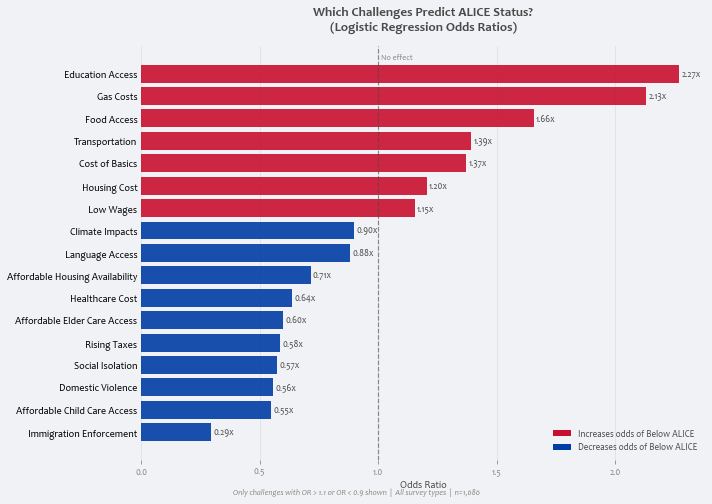

Saved: lr_alice_odds_ratios.png


In [129]:

# ── STEP 1: PREPARE DATA ──────────────────────────────────────────────────────
df_model = df_sm[df_sm["alice_clean"].notna()].copy()
df_model["target"] = (df_model["alice_clean"] == "Below ALICE").astype(int)

print(f"Total samples: {len(df_model)}")
print(f"Below ALICE (1): {df_model['target'].sum()} ({df_model['target'].mean()*100:.1f}%)")
print(f"Above ALICE (0): {(df_model['target']==0).sum()} ({(df_model['target']==0).mean()*100:.1f}%)")

# ── STEP 2: FEATURE SET ───────────────────────────────────────────────────────
challenge_cols = [c for c in df_sm.columns
                  if c.startswith("biggest_challenge_")
                  and "None" not in c
                  and "Other" not in c
                  and c != "biggest_challenge_clean"]

X = df_model[challenge_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y = df_model["target"]

feature_names = [c.replace("biggest_challenge_", "").replace("_", " ")
                 for c in challenge_cols]

# ── STEP 3: CROSS VALIDATION ──────────────────────────────────────────────────
clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    clf, X, y, cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

print("\n── Logistic Regression: Cross Validation Results (Stratified 5-Fold) ──")
print(f"  Accuracy:  {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
print(f"  Precision: {scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}")
print(f"  Recall:    {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}")
print(f"  F1 Score:  {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")

# ── STEP 4: FIT ON FULL DATA FOR COEFFICIENTS ─────────────────────────────────
clf.fit(X, y)

# ── STEP 5: ODDS RATIOS ───────────────────────────────────────────────────────
# Odds ratio = exp(coefficient)
# OR > 1 → increases odds of being Below ALICE
# OR < 1 → decreases odds of being Below ALICE
coefficients = clf.coef_[0]
odds_ratios  = np.exp(coefficients)

# Bundle into dataframe for easy sorting
coef_df = pd.DataFrame({
    "Challenge":   feature_names,
    "Coefficient": coefficients,
    "Odds Ratio":  odds_ratios
}).sort_values("Odds Ratio", ascending=False)

print("\n── Odds Ratios (sorted) ──")
print("  OR > 1 = increases odds of being Below ALICE")
print("  OR < 1 = decreases odds of being Below ALICE\n")
for _, row in coef_df.iterrows():
    direction = "↑ Below ALICE" if row["Odds Ratio"] > 1 else "↓ Above ALICE"
    print(f"  {row['Challenge']:<35} OR={row['Odds Ratio']:.2f}  {direction}")

# ── STEP 6: VISUALIZE ODDS RATIOS ────────────────────────────────────────────
# Only show challenges with meaningful effect (OR > 1.1 or OR < 0.9)
plot_df = coef_df[
    (coef_df["Odds Ratio"] > 1.1) | (coef_df["Odds Ratio"] < 0.9)
].copy()

plot_df = plot_df.sort_values("Odds Ratio")

colors = [RED_ACCENT if or_ > 1 else BLUE_ACCENT
          for or_ in plot_df["Odds Ratio"]]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(plot_df["Challenge"], plot_df["Odds Ratio"],
               color=colors, alpha=0.9, zorder=2)

# Reference line at OR=1 (no effect)
ax.axvline(x=1, color=LABEL_COLOR, linewidth=1.2,
           linestyle="--", zorder=3, alpha=0.6)

ax.text(1.01, ax.get_ylim()[1] * 0.98, "No effect",
        fontsize=8, color=SUB_COLOR, va="top")

# Value labels
for bar, val in zip(bars, plot_df["Odds Ratio"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}x", va="center", fontsize=9, color=LABEL_COLOR)

ax.set_xlabel("Odds Ratio", fontsize=10, color=LABEL_COLOR)
ax.set_title("Which Challenges Predict ALICE Status?\n(Logistic Regression Odds Ratios)",
             fontsize=13, fontweight="bold", color=LABEL_COLOR, pad=16)

ax.tick_params(axis="y", length=0, labelsize=10)
ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED_ACCENT,  label="Increases odds of Below ALICE"),
    Patch(facecolor=BLUE_ACCENT, label="Decreases odds of Below ALICE"),
]
leg = ax.legend(handles=legend_elements, frameon=False,
                fontsize=9, loc="lower right")
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

fig.text(0.5, 0.01,
         "Only challenges with OR > 1.1 or OR < 0.9 shown  |  All survey types  |  n=1,686",
         ha="center", fontsize=8, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("lr_alice_odds_ratios.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: lr_alice_odds_ratios.png")

In [131]:

# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────
def cramers_v(chi2, n, r, k):
    """
    Cramér's V effect size for chi-square test
    chi2 = chi-square statistic
    n    = total sample size
    r    = number of rows in contingency table
    k    = number of columns in contingency table
    """
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def run_chi_square(df, col1, col2, label):
    """
    Runs chi-square test between two categorical columns.
    Returns chi2, p-value, Cramér's V, and interpretation.
    """
    # Drop nulls for both columns
    subset = df[[col1, col2]].dropna()
    n      = len(subset)

    # Build contingency table
    ct = pd.crosstab(subset[col1], subset[col2])

    # Run chi-square
    chi2, p, dof, expected = chi2_contingency(ct)

    # Cramér's V
    r, k = ct.shape
    v    = cramers_v(chi2, n, r, k)

    # Interpret effect size
    if v < 0.1:
        effect = "Weak"
    elif v < 0.3:
        effect = "Moderate"
    else:
        effect = "Strong"

    # Interpret significance
    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    return {
        "Comparison":   label,
        "N":            n,
        "Chi2":         round(chi2, 2),
        "p-value":      round(p, 4),
        "Sig":          sig,
        "Cramér's V":   round(v, 3),
        "Effect":       effect
    }

# ── SECTION 1: ALICE STATUS vs EACH CHALLENGE ─────────────────────────────────
print("═" * 70)
print("SECTION 1: ALICE Status vs Individual Challenges")
print("═" * 70)
print("Validates: Are challenge differences between ALICE groups statistically real?\n")

challenge_cols = [c for c in df_sm.columns
                  if c.startswith("biggest_challenge_")
                  and "None" not in c
                  and "Other" not in c
                  and c != "biggest_challenge_clean"]

alice_results = []
for col in challenge_cols:
    label = col.replace("biggest_challenge_", "").replace("_", " ")
    # Convert one-hot to string for chi-square
    df_sm[f"{col}_str"] = pd.to_numeric(df_sm[col], errors="coerce").map(
        {0: "Not Selected", 1: "Selected"}
    )
    result = run_chi_square(df_sm, "alice_clean", f"{col}_str", label)
    alice_results.append(result)
    # Clean up temp column
    df_sm.drop(columns=[f"{col}_str"], inplace=True)

alice_df = pd.DataFrame(alice_results).sort_values("Cramér's V", ascending=False)
print(alice_df[["Comparison", "N", "p-value", "Sig", "Cramér's V", "Effect"]].to_string(index=False))

# ── SECTION 2: FEEL HEARD vs ALICE STATUS ─────────────────────────────────────
print("\n" + "═" * 70)
print("SECTION 2: Feel Heard vs ALICE Status")
print("═" * 70)
print("Validates: Do ALICE and Above ALICE groups differ in feeling heard?\n")

result = run_chi_square(df_sm, "feel_heard_clean", "alice_clean",
                        "Feel Heard vs ALICE Status")
heard_alice_df = pd.DataFrame([result])
print(heard_alice_df[["Comparison", "N", "p-value", "Sig",
                       "Cramér's V", "Effect"]].to_string(index=False))

# ── SECTION 3: FEEL HEARD vs RACE/ETHNICITY ───────────────────────────────────
print("\n" + "═" * 70)
print("SECTION 3: Feel Heard vs Race/Ethnicity")
print("═" * 70)
print("Validates: Do racial groups differ significantly in feeling heard?\n")

result = run_chi_square(df_sm, "feel_heard_clean", "race_ethnicity_clean",
                        "Feel Heard vs Race/Ethnicity")
heard_race_df = pd.DataFrame([result])
print(heard_race_df[["Comparison", "N", "p-value", "Sig",
                      "Cramér's V", "Effect"]].to_string(index=False))

# ── SECTION 4: FEEL HEARD vs AGE GROUP ───────────────────────────────────────
print("\n" + "═" * 70)
print("SECTION 4: Feel Heard vs Age Group")
print("═" * 70)
print("Validates: Do age groups differ significantly in feeling heard?\n")

result = run_chi_square(df_sm, "feel_heard_clean", "age_group_clean",
                        "Feel Heard vs Age Group")
heard_age_df = pd.DataFrame([result])
print(heard_age_df[["Comparison", "N", "p-value", "Sig",
                     "Cramér's V", "Effect"]].to_string(index=False))

# ── SECTION 5: ALICE STATUS vs FEEL HEARD vs ENGAGEMENT ──────────────────────
print("\n" + "═" * 70)
print("SECTION 5: Want Involvement vs Key Variables")
print("═" * 70)
print("Validates: Are engagement differences statistically significant?\n")

for col, label in [("alice_clean",        "Want Involvement vs ALICE Status"),
                   ("feel_heard_clean",    "Want Involvement vs Feel Heard"),
                   ("age_group_clean",     "Want Involvement vs Age Group"),
                   ("race_ethnicity_clean","Want Involvement vs Race/Ethnicity")]:
    result = run_chi_square(df_sm, "want_involvement_clean", col, label)
    print(pd.DataFrame([result])[["Comparison", "N", "p-value", "Sig",
                                   "Cramér's V", "Effect"]].to_string(index=False))
    print()

══════════════════════════════════════════════════════════════════════
SECTION 1: ALICE Status vs Individual Challenges
══════════════════════════════════════════════════════════════════════
Validates: Are challenge differences between ALICE groups statistically real?

                      Comparison     N  p-value  Sig  Cramér's V    Effect
                     Food Access  1686   0.0000  ***       0.122  Moderate
    Affordable Child Care Access  1686   0.0000  ***       0.121  Moderate
    Affordable Elder Care Access  1686   0.0000  ***       0.104  Moderate
                 Healthcare Cost  1686   0.0000  ***       0.100      Weak
                  Cost of Basics  1686   0.0019   **       0.075      Weak
                Social Isolation  1686   0.0030   **       0.072      Weak
                  Transportation  1686   0.0079   **       0.065      Weak
                Education Access  1686   0.0273    *       0.054      Weak
                    Housing Cost  1686   0.1683   ns   

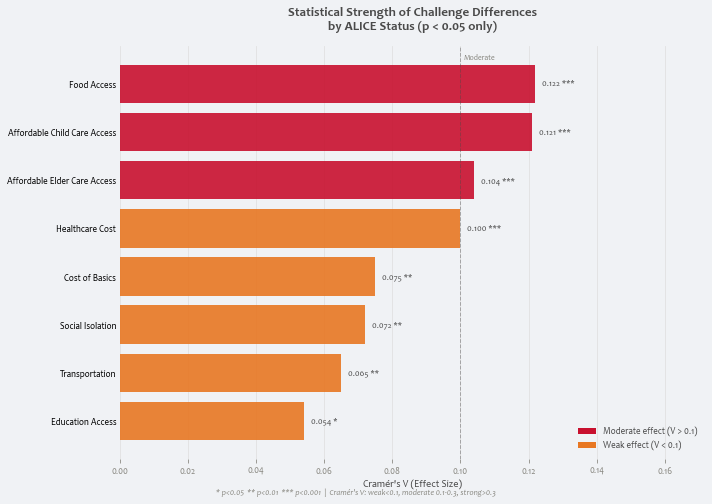


Saved: chi_square_alice_challenges.png


In [133]:
# ── VISUALIZATION: ALICE vs CHALLENGES HEATMAP ────────────────────────────────
# Show Cramér's V for each challenge as a horizontal bar
# Filter to only significant results (p < 0.05)
sig_df = alice_df[alice_df["p-value"] < 0.05].sort_values("Cramér's V")

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bar_colors = [RED_ACCENT if v > 0.1 else AMBER_ACCENT
              for v in sig_df["Cramér's V"]]

bars = ax.barh(sig_df["Comparison"], sig_df["Cramér's V"],
               color=bar_colors, alpha=0.9, zorder=2)

# Add significance stars
for bar, (_, row) in zip(bars, sig_df.iterrows()):
    v_val   = row["Cramér's V"]
    sig_val = row["Sig"]
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f"{v_val:.3f} {sig_val}",
            va="center", fontsize=8.5, color=LABEL_COLOR)

# Reference lines
ax.axvline(x=0.1, color=LABEL_COLOR, linewidth=1,
           linestyle="--", alpha=0.4, zorder=3)
ax.text(0.101, len(sig_df) - 0.5, "Moderate",
        fontsize=7.5, color=SUB_COLOR)

ax.set_xlabel("Cramér's V (Effect Size)", fontsize=10, color=LABEL_COLOR)
ax.set_title(
    "Statistical Strength of Challenge Differences\nby ALICE Status (p < 0.05 only)",
    fontsize=13, fontweight="bold", color=LABEL_COLOR, pad=16
)
ax.set_xlim(0, max(sig_df["Cramér's V"]) + 0.05)
ax.tick_params(axis="y", length=0, labelsize=9)
ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=9)
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED_ACCENT,   label="Moderate effect (V > 0.1)"),
    Patch(facecolor=AMBER_ACCENT, label="Weak effect (V < 0.1)"),
]
leg = ax.legend(handles=legend_elements, frameon=False,
                fontsize=9, loc="lower right")
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

fig.text(0.5, 0.01,
         "* p<0.05  ** p<0.01  *** p<0.001  |  Cramér's V: weak<0.1, moderate 0.1-0.3, strong>0.3",
         ha="center", fontsize=8, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("chi_square_alice_challenges.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("\nSaved: chi_square_alice_challenges.png")

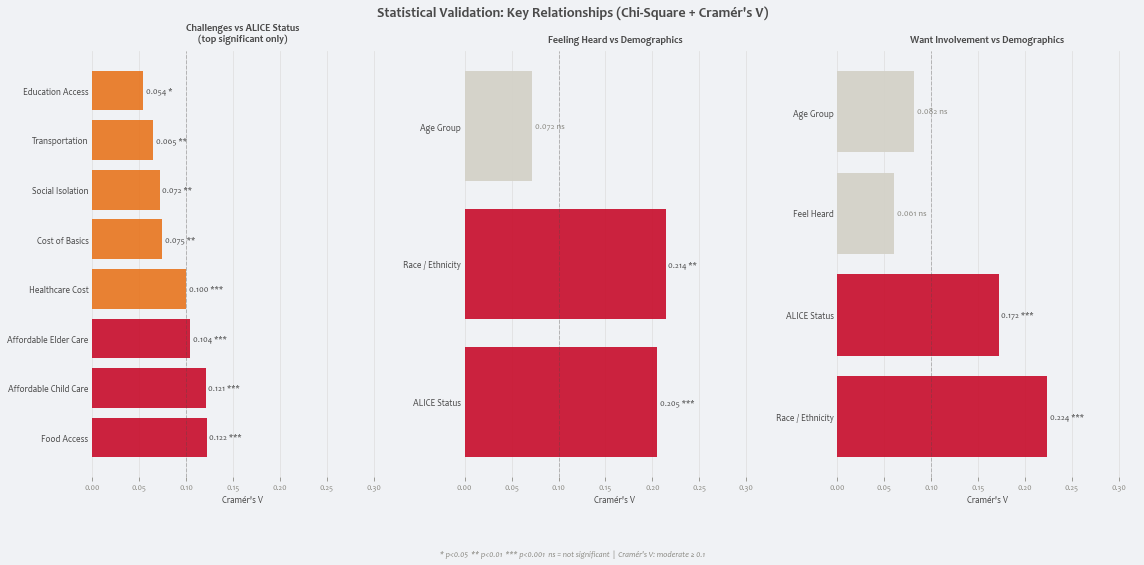

Saved: slide_chi_square_summary.png


In [134]:

# ── DATA — all statistically significant relationships ────────────────────────
# Grouped by theme, excluding challenge vs ALICE (already have dumbbell for that)

sections = {
    "Challenges vs ALICE Status\n(top significant only)": [
        ("Food Access",                0.122, "***", "Moderate"),
        ("Affordable Child Care",      0.121, "***", "Moderate"),
        ("Affordable Elder Care",      0.104, "***", "Moderate"),
        ("Healthcare Cost",            0.100, "***", "Weak"),
        ("Cost of Basics",             0.075, "**",  "Weak"),
        ("Social Isolation",           0.072, "**",  "Weak"),
        ("Transportation",             0.065, "**",  "Weak"),
        ("Education Access",           0.054, "*",   "Weak"),
    ],
    "Feeling Heard vs Demographics": [
        ("ALICE Status",               0.205, "***", "Moderate"),
        ("Race / Ethnicity",           0.214, "**",  "Moderate"),
        ("Age Group",                  0.072, "ns",  "Weak"),      # not sig — shown for contrast
    ],
    "Want Involvement vs Demographics": [
        ("Race / Ethnicity",           0.224, "***", "Moderate"),
        ("ALICE Status",               0.172, "***", "Moderate"),
        ("Feel Heard",                 0.061, "ns",  "Weak"),      # not sig
        ("Age Group",                  0.082, "ns",  "Weak"),      # not sig
    ],
}

# ── COLOR LOGIC ───────────────────────────────────────────────────────────────
def bar_color(sig, effect):
    if sig == "ns":
        return "#D3D1C7"        # gray — not significant
    elif effect == "Moderate":
        return RED_ACCENT       # red — significant + moderate
    else:
        return AMBER_ACCENT     # amber — significant + weak

# ── FIGURE: 3 subplots stacked ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Statistical Validation: Key Relationships (Chi-Square + Cramér's V)",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, y=1.01
)

for ax, (section_title, items) in zip(axes, sections.items()):
    ax.set_facecolor(BG_COLOR)

    labels  = [item[0] for item in items]
    values  = [item[1] for item in items]
    sigs    = [item[2] for item in items]
    effects = [item[3] for item in items]
    colors  = [bar_color(s, e) for s, e in zip(sigs, effects)]

    y_pos = np.arange(len(labels))
    bars  = ax.barh(y_pos, values, color=colors, alpha=0.92, zorder=2)

    # Value labels
    for bar, val, sig in zip(bars, values, sigs):
        label = f"{val:.3f} {sig}"
        ax.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height()/2,
                label, va="center", fontsize=8.5,
                color=LABEL_COLOR if sig != "ns" else SUB_COLOR)

    # Moderate reference line
    ax.axvline(x=0.1, color=LABEL_COLOR, linewidth=1,
               linestyle="--", alpha=0.3, zorder=3)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9, color=LABEL_COLOR)
    ax.set_xlabel("Cramér's V", fontsize=9, color=LABEL_COLOR)
    ax.set_title(section_title, fontsize=10, fontweight="bold",
                 color=LABEL_COLOR, pad=10)
    ax.set_xlim(0, 0.32)
    ax.tick_params(axis="x", colors=SUB_COLOR, labelsize=8)
    ax.tick_params(axis="y", length=0)
    ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
    ax.yaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── SHARED LEGEND ─────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=RED_ACCENT,   label="Significant + Moderate effect"),
    mpatches.Patch(facecolor=AMBER_ACCENT, label="Significant + Weak effect"),
    mpatches.Patch(facecolor="#D3D1C7",    label="Not significant (shown for context)"),
]
leg = fig.legend(handles=legend_elements,
                 loc="lower center", ncol=3,
                 frameon=False, fontsize=9,
                 bbox_to_anchor=(0.5, -0.04))
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

fig.text(0.5, -0.08,
         "* p<0.05  ** p<0.01  *** p<0.001  ns = not significant  |  Cramér's V: moderate ≥ 0.1",
         ha="center", fontsize=8, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("slide_chi_square_summary.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: slide_chi_square_summary.png")

Samples: 1686, Features: 24

Variance explained:
  PC1: 9.1%
  PC2: 7.0%
  Total: 16.2%

Top 5 challenges driving PC1:
Housing Cost                    0.549495
Cost of Basics                  0.468603
Healthcare Cost                 0.347051
Mental Health                   0.321832
Affordable Child Care Access    0.296891
Name: PC1, dtype: float64

Top 5 challenges driving PC2:
Lack of in Home Support            0.649996
Affordable Housing Availability    0.474425
Domestic Violence                  0.312915
Political Division                 0.250422
Immigration Enforcement            0.228889
Name: PC2, dtype: float64


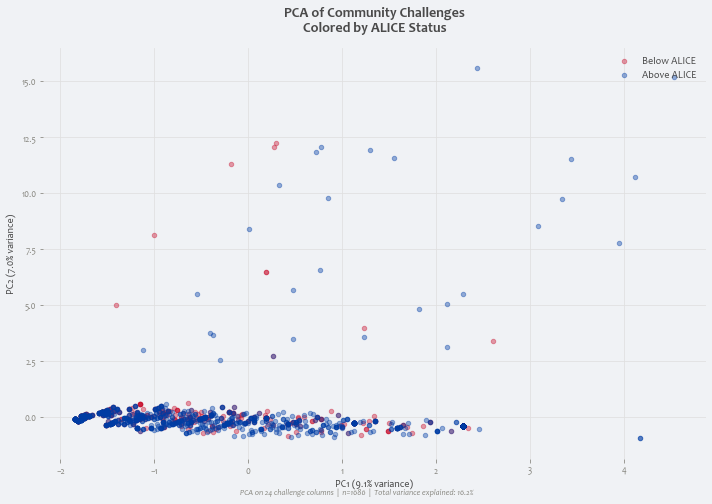

Saved: pca_alice_basic.png


In [139]:
# ── STEP 1: PREPARE DATA ──────────────────────────────────────────────────────
challenge_cols = [c for c in df_sm.columns
                  if c.startswith("biggest_challenge_")
                  and "None" not in c
                  and "Other" not in c
                  and c != "biggest_challenge_clean"]

df_pca = df_sm[df_sm["alice_clean"].notna()].copy()

X = df_pca[challenge_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
feature_names = [c.replace("biggest_challenge_", "").replace("_", " ")
                 for c in challenge_cols]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")

# ── STEP 2: SCALE + PCA ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVariance explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# ── STEP 3: TOP LOADINGS ──────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

print("\nTop 5 challenges driving PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print("\nTop 5 challenges driving PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

# ── STEP 4: SCATTER PLOT COLORED BY ALICE STATUS ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

colors_map = {
    "Below ALICE": RED_ACCENT,
    "Above ALICE": BLUE_ACCENT
}

for group, color in colors_map.items():
    mask = df_pca["alice_clean"] == group
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=group,
        alpha=0.4, s=20, zorder=2
    )

# Variance explained on axis labels
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",
              fontsize=10, color=LABEL_COLOR)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)",
              fontsize=10, color=LABEL_COLOR)

ax.set_title(
    "PCA of Community Challenges\nColored by ALICE Status",
    fontsize=14, fontweight="bold", color=LABEL_COLOR, pad=16
)

ax.tick_params(colors=SUB_COLOR, labelsize=9)
ax.xaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
ax.yaxis.grid(True, color="#E0E0E0", linewidth=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

leg = ax.legend(frameon=False, fontsize=10, loc="upper right")
for text in leg.get_texts():
    text.set_color(LABEL_COLOR)

fig.text(0.5, 0.01,
         f"PCA on {X.shape[1]} challenge columns  |  n={X.shape[0]}  |  Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%",
         ha="center", fontsize=8, color=SUB_COLOR, style="italic")

plt.tight_layout()
plt.savefig("pca_alice_basic.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: pca_alice_basic.png")